# Diffusion Models for Multivariate Time Series Anomaly Detection — Automotive Ethernet IDS

Comparative analysis of **diffusion-based** anomaly detection frameworks on the **TOW-IDS Automotive Ethernet** dataset. This notebook implements, trains, and evaluates six denoising-diffusion approaches — spanning reconstruction-based, imputation-based, forecasting-adapted, and generation-adapted paradigms — and compares them on detection accuracy, latency, model size, and energy consumption.

Uses the same data pipeline, windowed feature engineering, and evaluation protocol as the companion **TOW-IDS ML** notebook, enabling direct comparison with GAN-based and classical ML baselines.

### Frameworks Implemented

| # | Model | Paradigm | Eval Level | Reference |
|---|-------|----------|------------|-----------|
| 1 | **Diffusion (DDPM)** | Reconstruction | Sequence | Pintilie et al., IEEE ICDM-W |
| 2 | **DiffusionAE** | Autoencoder + Diffusion | Sequence | Pintilie et al., IEEE ICDM-W |
| 3 | **ImDiffusion** | Imputation-Diffusion | Sequence | Chen et al., 2023 (Microsoft) |
| 4 | **DiffAD** | Imputation + Weight-Incremental Diffusion | Sequence | Xiao et al., KDD 2023 |
| 5 | **DiffADT** | Reconstruction + S4 + Entity Embedding | Sequence | Zuo et al., Applied Intelligence 2024 |
| 6 | **TimeGrad** | Autoregressive Diffusion Forecasting | Sequence | Rasul et al., ICML 2021 |
| 7 | **Diffusion-TS** | Generation (Transformer + Decomposition) | Sequence | Yuan & Qiao, ICLR 2024 |

In [1]:
import os
import math
import random
import time
import threading
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
from sklearn.svm import OneClassSVM

import pynvml
import psutil

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# === File paths (same TOW-IDS Automotive Ethernet dataset) ===
TRAIN_PCAP = "/mnt/c/Users/rkiran97/Desktop/Datasets/Automotive Ethernet Dataset/Automotive_Ethernet_with_Attack_original_10_17_19_50_training.pcap"
TEST_PCAP  = "/mnt/c/Users/rkiran97/Desktop/Datasets/Automotive Ethernet Dataset/Automotive_Ethernet_with_Attack_original_10_17_20_04_test.pcap"
OUT_DIR = "/mnt/c/Users/rkiran97/Desktop/Datasets/Automotive Ethernet Dataset/extracted"

y_train_path = "/mnt/c/Users/rkiran97/Desktop/Datasets/Automotive Ethernet Dataset/y_train.csv"
y_test_path  = "/mnt/c/Users/rkiran97/Desktop/Datasets/Automotive Ethernet Dataset/y_test.csv"

# === Defaults ===
WINDOW_SEC     = 1.0       # window aggregation interval (seconds)
T_SEQ          = 40        # sequence length for temporal models (windows)
STRIDE         = 1         # sliding window stride
N_DIFF_STEPS   = 100       # diffusion timesteps T
BETA_START     = 1e-4      # linear noise schedule start
BETA_END       = 0.02      # linear noise schedule end
THR_PCT        = 99        # anomaly threshold percentile (fit on train-normal scores)
BATCH_SIZE     = 256
EPOCHS         = 100
LR             = 1e-4
ZDIM           = 16        # latent dimension
SEED           = 42

In [3]:
# =============================================
# Utility Functions (used throughout notebook)
# =============================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def model_size_stats(model):
    params = sum(p.numel() for p in model.parameters())
    bytes_ = sum(p.numel() * p.element_size() for p in model.parameters())
    return {"Params": int(params), "Size (MB)": float(bytes_ / 1024**2)}


def combined_model_size(*models):
    params = 0
    bytes_ = 0
    for m in models:
        params += sum(p.numel() for p in m.parameters())
        bytes_ += sum(p.numel() * p.element_size() for p in m.parameters())
    return {"Params": int(params), "Size (MB)": float(bytes_ / 1024**2)}


def measure_latency_ms(fn, runs=200):
    times = []
    for _ in range(runs):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        fn()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.mean(times) * 1000)


def measure_peak_cuda_mem_mb(fn):
    if not torch.cuda.is_available():
        return 0.0
    torch.cuda.reset_peak_memory_stats()
    fn()
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated() / 1024**2


def repeat_workload(fn, n=200):
    def _wrapped():
        for _ in range(n):
            fn()
    return _wrapped


def compute_metrics(y_true, scores, thr):
    y_pred = (scores >= thr).astype(int)
    return {
        "roc_auc":   float(roc_auc_score(y_true, scores)) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc":    float(average_precision_score(y_true, scores)) if len(np.unique(y_true)) > 1 else np.nan,
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "accuracy":  float(accuracy_score(y_true, y_pred)),
    }


def compute_metrics_auto_thr(y_true, scores_test, scores_train_normal, thr_pct=99):
    thr = np.percentile(scores_train_normal, thr_pct)
    return compute_metrics(y_true, scores_test, thr)


# =============================================
# Profiling / Energy Measurement Utilities
# =============================================

def nvml_energy_joules(workload_fn, device_index=0, sample_ms=10):
    pynvml.nvmlInit()
    h = pynvml.nvmlDeviceGetHandleByIndex(device_index)

    workload_fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    samples_t, samples_p = [], []
    stop = threading.Event()

    def sampler():
        t0 = time.perf_counter()
        while not stop.is_set():
            t = time.perf_counter() - t0
            p = pynvml.nvmlDeviceGetPowerUsage(h) / 1000.0
            samples_t.append(t)
            samples_p.append(p)
            time.sleep(sample_ms / 1000.0)

    th = threading.Thread(target=sampler, daemon=True)
    th.start()
    t_start = time.perf_counter()
    workload_fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t_start
    stop.set()
    th.join(timeout=1.0)
    pynvml.nvmlShutdown()

    if len(samples_t) >= 2:
        energy_j = float(np.trapz(np.array(samples_p), np.array(samples_t)))
    else:
        energy_j = float(np.mean(samples_p) * elapsed) if samples_p else np.nan
    avg_power = energy_j / elapsed if elapsed > 0 else np.nan
    return energy_j, avg_power, elapsed


def profile_workload(fn, repeats=200, device_index=0, sample_ms=10):
    pynvml.nvmlInit()
    h = pynvml.nvmlDeviceGetHandleByIndex(device_index)
    proc = psutil.Process()
    stop = threading.Event()

    gpu_power_w, gpu_util, gpu_mem_mb, cpu_util, rss_mb, ts = [], [], [], [], [], []

    def sampler():
        t0 = time.perf_counter()
        while not stop.is_set():
            now = time.perf_counter() - t0
            ts.append(now)
            p = pynvml.nvmlDeviceGetPowerUsage(h) / 1000.0
            u = pynvml.nvmlDeviceGetUtilizationRates(h)
            mem = pynvml.nvmlDeviceGetMemoryInfo(h)
            gpu_power_w.append(p)
            gpu_util.append(float(u.gpu))
            gpu_mem_mb.append(mem.used / 1024**2)
            cpu_util.append(psutil.cpu_percent(interval=None))
            rss_mb.append(proc.memory_info().rss / 1024**2)
            time.sleep(sample_ms / 1000.0)

    fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    th = threading.Thread(target=sampler, daemon=True)
    th.start()
    t0 = time.perf_counter()
    for _ in range(repeats):
        fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    stop.set()
    th.join(timeout=1.0)
    pynvml.nvmlShutdown()

    energy_j = float(np.trapz(np.array(gpu_power_w), np.array(ts))) if len(ts) >= 2 else (float(np.mean(gpu_power_w) * elapsed) if gpu_power_w else np.nan)

    return {
        "Elapsed (s)": elapsed,
        "Latency (ms)": elapsed * 1000.0 / repeats,
        "Throughput (calls/s)": repeats / elapsed,
        "GPU Power Avg (W)": float(np.mean(gpu_power_w)) if gpu_power_w else np.nan,
        "GPU Power Peak (W)": float(np.max(gpu_power_w)) if gpu_power_w else np.nan,
        "GPU Util Avg (%)": float(np.mean(gpu_util)) if gpu_util else np.nan,
        "GPU Mem Avg (MB)": float(np.mean(gpu_mem_mb)) if gpu_mem_mb else np.nan,
        "GPU Mem Peak (MB)": float(np.max(gpu_mem_mb)) if gpu_mem_mb else np.nan,
        "CPU Util Avg (%)": float(np.mean(cpu_util)) if cpu_util else np.nan,
        "RSS Peak (MB)": float(np.max(rss_mb)) if rss_mb else np.nan,
        "Energy Total (J)": energy_j,
        "Energy (J/call)": energy_j / repeats if np.isfinite(energy_j) else np.nan,
    }

In [4]:
# =============================================
# Diffusion Noise Schedule Utilities
# =============================================

def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)


def cosine_beta_schedule(T, s=0.008):
    steps = torch.arange(T + 1, dtype=torch.float64)
    alphas_bar = torch.cos(((steps / T) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_bar = alphas_bar / alphas_bar[0]
    betas = 1 - (alphas_bar[1:] / alphas_bar[:-1])
    return torch.clamp(betas, 0.0001, 0.9999).float()


class DiffusionSchedule:
    """Precompute and store all noise schedule quantities."""
    def __init__(self, T, schedule="linear", beta_start=1e-4, beta_end=0.02):
        if schedule == "cosine":
            betas = cosine_beta_schedule(T)
        else:
            betas = linear_beta_schedule(T, beta_start, beta_end)

        alphas = 1.0 - betas
        alphas_bar = torch.cumprod(alphas, dim=0)
        alphas_bar_prev = F.pad(alphas_bar[:-1], (1, 0), value=1.0)

        self.T = T
        self.betas = betas
        self.alphas = alphas
        self.alphas_bar = alphas_bar
        self.alphas_bar_prev = alphas_bar_prev
        self.sqrt_alphas_bar = torch.sqrt(alphas_bar)
        self.sqrt_one_minus_alphas_bar = torch.sqrt(1.0 - alphas_bar)
        self.posterior_var = betas * (1.0 - alphas_bar_prev) / (1.0 - alphas_bar)

    def to(self, device):
        for attr in ["betas", "alphas", "alphas_bar", "alphas_bar_prev",
                      "sqrt_alphas_bar", "sqrt_one_minus_alphas_bar", "posterior_var"]:
            setattr(self, attr, getattr(self, attr).to(device))
        return self


def q_sample(x_0, t, schedule, noise=None):
    """Forward diffusion: add noise at timestep t."""
    if noise is None:
        noise = torch.randn_like(x_0)
    sqrt_ab = schedule.sqrt_alphas_bar[t].view(-1, *([1] * (x_0.dim() - 1)))
    sqrt_omab = schedule.sqrt_one_minus_alphas_bar[t].view(-1, *([1] * (x_0.dim() - 1)))
    return sqrt_ab * x_0 + sqrt_omab * noise


def p_sample(model, x_t, t, schedule):
    """Reverse diffusion: denoise one step."""
    betas = schedule.betas[t].view(-1, *([1] * (x_t.dim() - 1)))
    sqrt_omab = schedule.sqrt_one_minus_alphas_bar[t].view(-1, *([1] * (x_t.dim() - 1)))
    sqrt_recip_alpha = (1.0 / torch.sqrt(schedule.alphas[t])).view(-1, *([1] * (x_t.dim() - 1)))
    eps_pred = model(x_t, t)
    mean = sqrt_recip_alpha * (x_t - betas / sqrt_omab * eps_pred)
    if t[0].item() == 0:
        return mean
    noise = torch.randn_like(x_t)
    sigma = torch.sqrt(schedule.posterior_var[t]).view(-1, *([1] * (x_t.dim() - 1)))
    return mean + sigma * noise


@torch.no_grad()
def p_sample_loop(model, shape, schedule):
    """Full reverse diffusion from noise to sample."""
    x = torch.randn(shape, device=schedule.betas.device)
    for i in reversed(range(schedule.T)):
        t = torch.full((shape[0],), i, device=x.device, dtype=torch.long)
        x = p_sample(model, x, t, schedule)
    return x

## 1. Data Ingestion

Same pcap extraction and label-merge pipeline as **TOW-IDS ML** notebook.

In [5]:
import shlex, subprocess

os.makedirs(OUT_DIR, exist_ok=True)

train_csv = f"{OUT_DIR}/packets_train.csv"
cmd = f"""
tshark -r {shlex.quote(TRAIN_PCAP)} \
  -T fields -E header=y -E separator=, -E quote=d \
  -e frame.number -e frame.time_epoch -e frame.len \
  -e eth.src -e eth.dst -e eth.type \
  -e vlan.id -e ip.src -e ip.dst -e ip.proto \
  -e tcp.srcport -e tcp.dstport -e udp.srcport -e udp.dstport
"""
if not os.path.exists(train_csv):
    subprocess.run(cmd, shell=True, stdout=open(train_csv, "w"), check=True)
train_pkts = pd.read_csv(train_csv)
print(f"Train packets: {len(train_pkts)}")

test_csv = f"{OUT_DIR}/packets_test.csv"
cmd_test = cmd.replace(TRAIN_PCAP, TEST_PCAP)
if not os.path.exists(test_csv):
    subprocess.run(cmd_test, shell=True, stdout=open(test_csv, "w"), check=True)
test_pkts = pd.read_csv(test_csv)
print(f"Test packets: {len(test_pkts)}")

Train packets: 1203737
Test packets: 791611


In [6]:
# Load labels
y_train = pd.read_csv(y_train_path, header=None)
y_test  = pd.read_csv(y_test_path,  header=None)
y_train.columns = ["sample_number", "normal_or_abnormal", "attack_type"]
y_test.columns  = ["sample_number", "normal_or_abnormal", "attack_type"]

# Convert "Normal"/"Abnormal" → 0/1 integer labels
train_pkts["y"] = (y_train["normal_or_abnormal"].values[:len(train_pkts)] != "Normal").astype(int)
test_pkts["y"]  = (y_test["normal_or_abnormal"].values[:len(test_pkts)] != "Normal").astype(int)

# Attach attack_type labels
for df, ydf in [(train_pkts, y_train), (test_pkts, y_test)]:
    df["attack_type"] = ydf["attack_type"].values[:len(df)]
    df["attack_type"] = df["attack_type"].astype(str).str.strip()
    df.loc[df["y"] == 0, "attack_type"] = "normal"

print("Train labels:", train_pkts["y"].value_counts().to_dict())
print("Test labels:",  test_pkts["y"].value_counts().to_dict())
print("Attack types:", sorted(test_pkts.loc[test_pkts["y"] == 1, "attack_type"].unique()))

Train labels: {0: 954912, 1: 248825}
Test labels: {0: 660777, 1: 130834}
Attack types: ['C_D', 'C_R', 'F_I', 'M_F', 'P_I']


## 2. Feature Engineering

Same windowed aggregation as **TOW-IDS ML**: each 1-second window produces a feature vector summarizing packet counts, byte statistics, inter-arrival times, and protocol diversity. Sequences of consecutive windows are then built for temporal diffusion models.

In [7]:
def get_feature_cols(df):
    return [c for c in df.columns if c not in ["w", "y_window", "attack_type_window"]]


def build_global_windows_with_attack(df, window_sec=1.0):
    """Build windowed features with attack-type labels (same as TOW-IDS ML)."""
    df = df.copy()
    df["t"] = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.dropna(subset=["t"]).sort_values("t")

    t0 = df["t"].iloc[0]
    df["w"] = np.floor((df["t"] - t0) / window_sec).astype(int)
    df["frame.len"] = pd.to_numeric(df["frame.len"], errors="coerce").fillna(0.0)
    df["dt"] = df["t"].diff().fillna(0.0).clip(lower=0.0)
    df["is_multicast"] = df["eth.dst"].astype(str).str.lower().str.startswith(("01:", "33:")).astype(int)
    df["has_vlan"] = df["vlan.id"].notna().astype(int)

    def agg(g):
        # y is already integer 0/1 from cell 7
        y_vals = g["y"].values
        y_win = int(y_vals.max())
        if y_win == 0:
            atk = "normal"
        else:
            atk_series = g.loc[g["y"] == 1, "attack_type"].astype(str).str.strip()
            atk_series = atk_series[atk_series != "normal"]
            atk = atk_series.value_counts().index[0] if len(atk_series) else "anomaly"

        return pd.Series({
            "pkt_count": len(g),
            "bytes_sum": g["frame.len"].sum(),
            "pkt_len_mean": g["frame.len"].mean(),
            "pkt_len_std": g["frame.len"].std(ddof=0),
            "dt_mean": g["dt"].mean(),
            "dt_std": g["dt"].std(ddof=0),
            "uniq_src_mac": g["eth.src"].nunique(dropna=True),
            "uniq_dst_mac": g["eth.dst"].nunique(dropna=True),
            "uniq_ip_src": g["ip.src"].nunique(dropna=True),
            "uniq_ip_dst": g["ip.dst"].nunique(dropna=True),
            "uniq_eth_type": g["eth.type"].nunique(dropna=True),
            "multicast_ratio": g["is_multicast"].mean(),
            "vlan_ratio": g["has_vlan"].mean(),
            "y_window": y_win,
            "attack_type_window": atk,
        })

    return df.groupby("w").apply(agg).reset_index()


train_w = build_global_windows_with_attack(train_pkts, window_sec=WINDOW_SEC)
test_w  = build_global_windows_with_attack(test_pkts,  window_sec=WINDOW_SEC)
print(f"Train windows: {len(train_w)} (normal: {(train_w['y_window']==0).sum()}, attack: {(train_w['y_window']==1).sum()})")
print(f"Test windows:  {len(test_w)} (normal: {(test_w['y_window']==0).sum()}, attack: {(test_w['y_window']==1).sum()})")
print(f"Test attack types: {sorted(test_w.loc[test_w['y_window']==1, 'attack_type_window'].unique())}")

Train windows: 553 (normal: 273, attack: 280)
Test windows:  397 (normal: 240, attack: 157)
Test attack types: ['C_D', 'C_R', 'F_I', 'M_F', 'P_I']


In [8]:
def make_sequences(df, t_seq=40, stride=1, feature_cols=None):
    """Build sliding-window sequences for temporal anomaly detection models."""
    df = df.sort_values("w").reset_index(drop=True)
    if feature_cols is None:
        feature_cols = get_feature_cols(df)
    X = df[feature_cols].astype(float).fillna(0.0).to_numpy()
    y = df["y_window"].astype(int).to_numpy()
    atk = df["attack_type_window"].astype(str).to_numpy() if "attack_type_window" in df.columns else np.array(["normal"] * len(df))

    seqs, seq_y, seq_atk = [], [], []
    for start in range(0, len(df) - t_seq + 1, stride):
        end = start + t_seq
        seqs.append(X[start:end])
        y_s = int(y[start:end].max())
        seq_y.append(y_s)
        if y_s == 0:
            seq_atk.append("normal")
        else:
            anom_types = atk[start:end][y[start:end] == 1]
            seq_atk.append(pd.Series(anom_types).value_counts().index[0] if len(anom_types) else "anomaly")

    return np.stack(seqs), np.array(seq_y), np.array(seq_atk)


def seq_scores_to_window_scores(seq_scores, n_windows, t_seq, agg="mean"):
    """Map sequence-level scores back to window-level scores."""
    accum = np.zeros(n_windows)
    count = np.zeros(n_windows)
    for i, s in enumerate(seq_scores):
        for j in range(t_seq):
            idx = i + j
            if idx < n_windows:
                accum[idx] += s
                count[idx] += 1
    count[count == 0] = 1
    if agg == "mean":
        return accum / count
    return accum  # max-like via accumulation


# Build sequences
feature_cols = get_feature_cols(train_w)
D_feat = len(feature_cols)
print(f"Feature dimensionality: {D_feat}")

# Scale features (fit on train-normal only)
scaler = StandardScaler()
train_normal = train_w[train_w["y_window"] == 0]
scaler.fit(train_normal[feature_cols].astype(float).fillna(0.0))

train_w_scaled = train_w.copy()
test_w_scaled  = test_w.copy()
train_w_scaled[feature_cols] = scaler.transform(train_w[feature_cols].astype(float).fillna(0.0))
test_w_scaled[feature_cols]  = scaler.transform(test_w[feature_cols].astype(float).fillna(0.0))

Xtr_all, ytr_seq, atr_seq = make_sequences(train_w_scaled, t_seq=T_SEQ, stride=STRIDE, feature_cols=feature_cols)
Xte_all, yte_seq, ate_seq = make_sequences(test_w_scaled,  t_seq=T_SEQ, stride=STRIDE, feature_cols=feature_cols)

# Train on normal sequences only
normal_mask = (ytr_seq == 0)
Xtr_normal = Xtr_all[normal_mask]

print(f"Train sequences: {len(Xtr_all)} (normal: {normal_mask.sum()}, attack: {(~normal_mask).sum()})")
print(f"Test sequences:  {len(Xte_all)} (normal: {(yte_seq==0).sum()}, attack: {(yte_seq==1).sum()})")
print(f"Sequence shape:  {Xtr_all.shape}  →  (N, T_SEQ={T_SEQ}, D={D_feat})")

Feature dimensionality: 13
Train sequences: 514 (normal: 67, attack: 447)
Test sequences:  358 (normal: 62, attack: 296)
Sequence shape:  (514, 40, 13)  →  (N, T_SEQ=40, D=13)


## 3. Exploratory Data Analysis

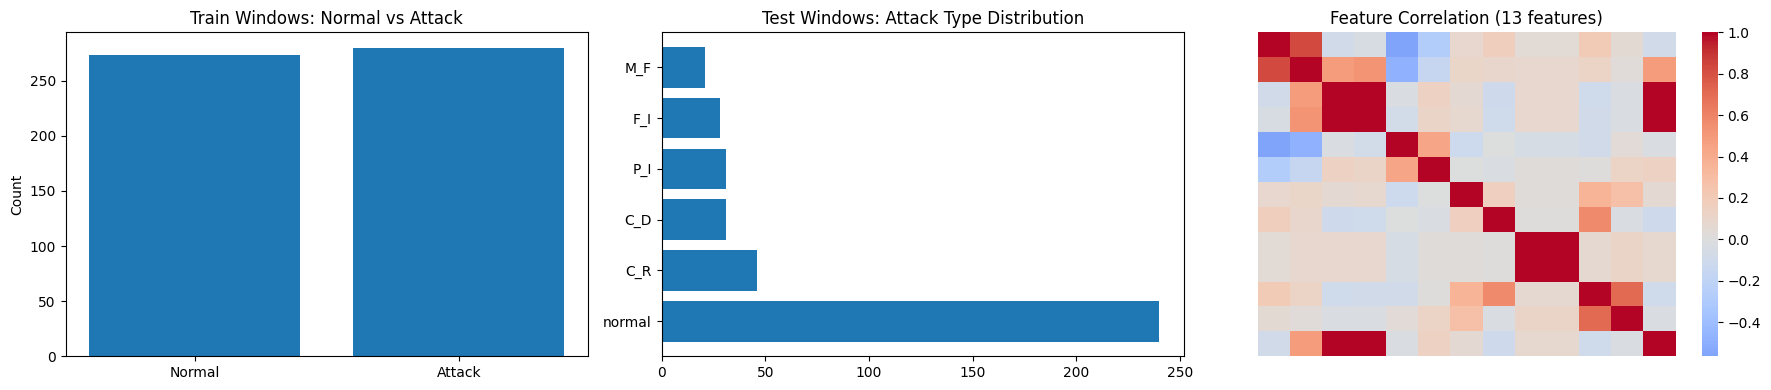


Sequence-level label distribution:
  Train: normal=67, attack=447
  Test:  normal=62, attack=296


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Window-level label distribution
axes[0].bar(["Normal", "Attack"], [len(train_w[train_w["y_window"]==0]), len(train_w[train_w["y_window"]==1])])
axes[0].set_title("Train Windows: Normal vs Attack")
axes[0].set_ylabel("Count")

# Attack type distribution in test
atk_counts = test_w["attack_type_window"].value_counts()
axes[1].barh(atk_counts.index, atk_counts.values)
axes[1].set_title("Test Windows: Attack Type Distribution")

# Feature correlation heatmap (normal windows only)
corr = train_normal[feature_cols].astype(float).corr()
sns.heatmap(corr, ax=axes[2], cmap="coolwarm", center=0, xticklabels=False, yticklabels=False)
axes[2].set_title(f"Feature Correlation ({D_feat} features)")

plt.tight_layout()
plt.show()

# Sequence-level stats
print(f"\nSequence-level label distribution:")
print(f"  Train: normal={normal_mask.sum()}, attack={(~normal_mask).sum()}")
print(f"  Test:  normal={(yte_seq==0).sum()}, attack={(yte_seq==1).sum()}")

## 4. Diffusion (DDPM Reconstruction)

**Reference:** Pintilie, I., Manolache, A., & Brad, F. *Time Series Anomaly Detection using Diffusion-based Models.* IEEE ICDM Workshops.

**Architecture:** Standard denoising diffusion probabilistic model (DDPM) with a 1D U-Net denoiser $\epsilon_\theta$.

**Training:** Learn to predict noise $\epsilon$ added at random timestep $n$:
$$\mathcal{L}_{\text{dif}} = \|\epsilon - \epsilon_\theta(\sqrt{\bar{\alpha}_n} X_0 + \sqrt{1-\bar{\alpha}_n}\,\epsilon,\; n)\|^2$$

**Anomaly Scoring (Algorithm 2 from paper):**
1. Add noise to test input $X_0$ for $M$ steps: $X_M \sim q(X_M | X_0)$
2. Iteratively denoise back: $\tilde{X}_0 = \text{denoise}(X_M)$
3. Anomaly score $= \frac{1}{D}\|X_0 - \tilde{X}_0\|^2$ per timestep

**Key Insight:** Trained on normal data only. The diffusion model learns the normal data distribution; anomalous segments cannot be faithfully reconstructed, producing high reconstruction error.

In [10]:
# =============================================
# 1D U-Net Denoiser for Time Series (Pintilie et al.)
# =============================================
# The denoiser operates on (batch, D_feat, T_SEQ) tensors — channels-first,
# analogous to (B, C, H) in image diffusion but for 1D temporal signals.

def _gn(ch):
    """GroupNorm with adaptive group count — handles any channel size."""
    for g in [8, 4, 2, 1]:
        if ch % g == 0:
            return nn.GroupNorm(g, ch)
    return nn.GroupNorm(1, ch)


class SinusoidalPosEmb(nn.Module):
    """Sinusoidal timestep embedding (same as image diffusion)."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device, dtype=torch.float32) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ResBlock1D(nn.Module):
    """ResNet block with time-embedding conditioning for 1D signals."""
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Sequential(_gn(in_ch), nn.SiLU(), nn.Conv1d(in_ch, out_ch, 3, padding=1))
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.conv2 = nn.Sequential(_gn(out_ch), nn.SiLU(), nn.Conv1d(out_ch, out_ch, 3, padding=1))
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = h + self.time_mlp(t_emb)[:, :, None]  # broadcast time emb over temporal dim
        h = self.conv2(h)
        return h + self.skip(x)


class UNet1D(nn.Module):
    """
    Minimal 1D U-Net for diffusion denoising (adapted from Pintilie et al.).
    Input:  (B, D_feat, T_SEQ) noisy sequence + (B,) integer timestep
    Output: (B, D_feat, T_SEQ) predicted noise
    """
    def __init__(self, in_channels, base_ch=64, ch_mults=(1, 2, 4), time_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim * 2),
            nn.SiLU(),
            nn.Linear(time_dim * 2, time_dim),
        )

        # Encoder
        self.enc_blocks = nn.ModuleList()
        self.down_samples = nn.ModuleList()
        prev_ch = in_channels
        enc_channels = []
        for mult in ch_mults:
            out_ch = base_ch * mult
            self.enc_blocks.append(ResBlock1D(prev_ch, out_ch, time_dim))
            self.down_samples.append(nn.Conv1d(out_ch, out_ch, 3, stride=2, padding=1))
            enc_channels.append(out_ch)
            prev_ch = out_ch

        # Bottleneck
        self.mid = ResBlock1D(prev_ch, prev_ch, time_dim)

        # Decoder
        self.dec_blocks = nn.ModuleList()
        self.up_samples = nn.ModuleList()
        for mult in reversed(ch_mults):
            out_ch = base_ch * mult
            self.up_samples.append(nn.ConvTranspose1d(prev_ch, out_ch, 4, stride=2, padding=1))
            self.dec_blocks.append(ResBlock1D(out_ch * 2, out_ch, time_dim))  # *2 for skip connection
            prev_ch = out_ch

        self.final = nn.Conv1d(prev_ch, in_channels, 1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Encoder path
        skips = []
        h = x
        for enc, down in zip(self.enc_blocks, self.down_samples):
            h = enc(h, t_emb)
            skips.append(h)
            h = down(h)

        # Bottleneck
        h = self.mid(h, t_emb)

        # Decoder path
        for up, dec, skip in zip(self.up_samples, self.dec_blocks, reversed(skips)):
            h = up(h)
            # Handle size mismatch from non-power-of-2 sequence lengths
            if h.shape[-1] != skip.shape[-1]:
                h = F.pad(h, (0, skip.shape[-1] - h.shape[-1]))
            h = torch.cat([h, skip], dim=1)
            h = dec(h, t_emb)

        return self.final(h)

In [11]:
# =============================================
# Training & Scoring — Pure Diffusion (Algorithm 1 & 2 from Pintilie et al.)
# =============================================

def train_diffusion(X_train, schedule, model, epochs=100, batch_size=256, lr=1e-4, seed=42):
    """Train DDPM denoiser on normal sequences."""
    set_seed(seed)
    # X_train: (N, T_SEQ, D) → transpose to (N, D, T_SEQ) for Conv1d
    X_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1).to(device)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for (x0_batch,) in loader:
            n = torch.randint(0, schedule.T, (x0_batch.size(0),), device=device)
            noise = torch.randn_like(x0_batch)
            x_noisy = q_sample(x0_batch, n, schedule, noise)
            pred_noise = model(x_noisy, n)
            loss = F.mse_loss(pred_noise, noise)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x0_batch.size(0)
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs}  loss={total_loss/len(X_t):.6f}")


@torch.no_grad()
def diffusion_score_sequences(model, X, schedule, M=50):
    """
    Anomaly scoring (Algorithm 2): add noise for M steps, denoise back,
    compute per-sequence reconstruction error.
    """
    model.eval()
    # X: (N, T_SEQ, D) → (N, D, T_SEQ)
    X_t = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1).to(device)
    scores = []

    for i in range(0, len(X_t), 256):
        batch = X_t[i:i+256]
        # Forward: add noise at level M
        t_M = torch.full((batch.size(0),), M - 1, device=device, dtype=torch.long)
        noisy = q_sample(batch, t_M, schedule)

        # Reverse: denoise M steps
        x = noisy
        for step in reversed(range(M)):
            t = torch.full((batch.size(0),), step, device=device, dtype=torch.long)
            x = p_sample(model, x, t, schedule)

        # Reconstruction error per sequence: mean over (D, T) dimensions
        err = (batch - x).pow(2).mean(dim=(1, 2))  # (B,)
        scores.append(err.cpu().numpy())

    return np.concatenate(scores)


# --- Train ---
print("Training DDPM Diffusion model...")
schedule_ddpm = DiffusionSchedule(N_DIFF_STEPS, schedule="linear",
                                   beta_start=BETA_START, beta_end=BETA_END).to(device)
ddpm_model = UNet1D(in_channels=D_feat, base_ch=64, ch_mults=(1, 2, 4)).to(device)
print(f"  Model params: {model_size_stats(ddpm_model)}")
train_diffusion(Xtr_normal, schedule_ddpm, ddpm_model, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, seed=SEED)

Training DDPM Diffusion model...
  Model params: {'Params': 2673127, 'Size (MB)': 10.19717025756836}
  Epoch 20/100  loss=0.965712
  Epoch 40/100  loss=0.882564
  Epoch 60/100  loss=0.816630
  Epoch 80/100  loss=0.719589
  Epoch 100/100  loss=0.647649


DDPM Diffusion metrics: {'roc_auc': '0.9736', 'pr_auc': '0.9915', 'f1': '0.9516', 'precision': '0.9105', 'recall': '0.9966', 'accuracy': '0.9162'}

Per-attack breakdown:


,attack_type,n_attack_seqs,TN,FP,FN,TP,precision,recall,f1,roc_auc,pr_auc
4,P_I,30,33,29,0,30,0.5085,1.0000,0.6742,1.0000,1.0000
3,M_F,58,33,29,0,58,0.6667,1.0000,0.8000,1.0000,1.0000
2,F_I,60,33,29,0,60,0.6742,1.0000,0.8054,0.9702,0.9266
1,C_R,81,33,29,0,81,0.7364,1.0000,0.8482,0.9642,0.9107
0,C_D,67,33,29,1,66,0.6947,0.9851,0.8148,0.9533,0.8988


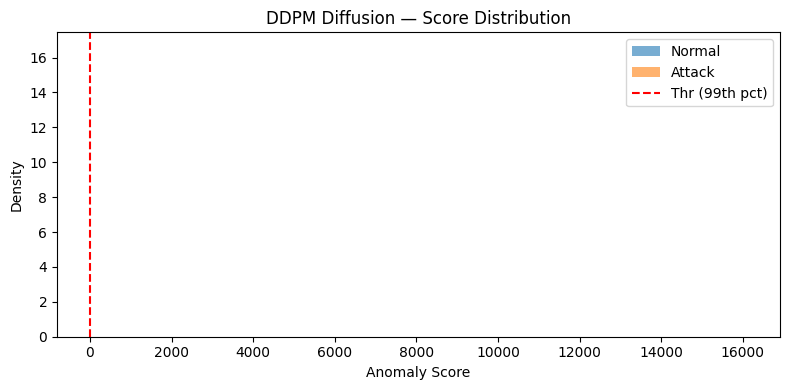


===== DDPM Diffusion Confusion Matrix (Sequence-Level) =====
TN=33  FP=29  FN=1  TP=295
Precision: 0.9105
Recall:    0.9966
F1:        0.9516


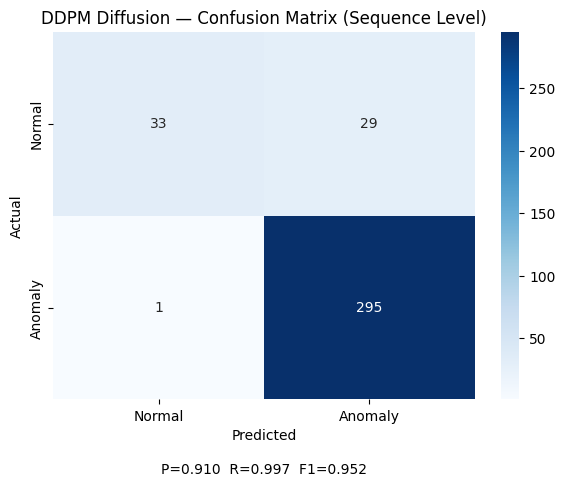

In [12]:
# --- Evaluate DDPM Diffusion ---
# Score using M=50 noise steps (paper tests M <= N)
M_SCORE = 50
ddpm_scores_tr = diffusion_score_sequences(ddpm_model, Xtr_all[normal_mask], schedule_ddpm, M=M_SCORE)
ddpm_scores_te = diffusion_score_sequences(ddpm_model, Xte_all, schedule_ddpm, M=M_SCORE)

ddpm_metrics = compute_metrics_auto_thr(yte_seq, ddpm_scores_te, ddpm_scores_tr, thr_pct=THR_PCT)
print("DDPM Diffusion metrics:", {k: f"{v:.4f}" for k, v in ddpm_metrics.items()})

# Per-attack one-vs-normal breakdown (with confusion matrix components)
ddpm_thr = np.percentile(ddpm_scores_tr, THR_PCT)
attacks = sorted([a for a in np.unique(ate_seq) if a != "normal"])
pa_rows = []
for atk in attacks:
    mask = (ate_seq == atk) | (ate_seq == "normal")
    y_sub = (ate_seq[mask] != "normal").astype(int)
    s_sub = ddpm_scores_te[mask]
    y_pred_sub = (s_sub >= ddpm_thr).astype(int)
    cm_sub = confusion_matrix(y_sub, y_pred_sub, labels=[0, 1])
    tn, fp, fn, tp = cm_sub.ravel()
    pa_rows.append({
        "attack_type": atk,
        "n_attack_seqs": int((ate_seq[mask] == atk).sum()),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "precision": precision_score(y_sub, y_pred_sub, zero_division=0),
        "recall": recall_score(y_sub, y_pred_sub, zero_division=0),
        "f1": f1_score(y_sub, y_pred_sub, zero_division=0),
        "roc_auc": roc_auc_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
    })
print("\nPer-attack breakdown:")
display(pd.DataFrame(pa_rows).sort_values("pr_auc", ascending=False).round(4))

# Score distribution
fig, ax = plt.subplots(figsize=(8, 4))
normal_s = ddpm_scores_te[yte_seq == 0]
attack_s = ddpm_scores_te[yte_seq == 1]
ax.hist(normal_s, bins=50, alpha=0.6, label="Normal", density=True)
ax.hist(attack_s, bins=50, alpha=0.6, label="Attack", density=True)
ax.axvline(ddpm_thr, color="red", linestyle="--", label=f"Thr ({THR_PCT}th pct)")
ax.set_title("DDPM Diffusion — Score Distribution")
ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Density"); ax.legend()
plt.tight_layout(); plt.show()

# Confusion matrix with printed metrics
y_pred_ddpm = (ddpm_scores_te >= ddpm_thr).astype(int)
cm = confusion_matrix(yte_seq, y_pred_ddpm)
tn, fp, fn, tp = cm.ravel()
print(f"\n===== DDPM Diffusion Confusion Matrix (Sequence-Level) =====")
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Precision: {precision_score(yte_seq, y_pred_ddpm):.4f}")
print(f"Recall:    {recall_score(yte_seq, y_pred_ddpm):.4f}")
print(f"F1:        {f1_score(yte_seq, y_pred_ddpm):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"], ax=ax)
ax.set_title("DDPM Diffusion — Confusion Matrix (Sequence Level)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.text(0.5, -0.2, f"P={precision_score(yte_seq, y_pred_ddpm):.3f}  R={recall_score(yte_seq, y_pred_ddpm):.3f}  F1={f1_score(yte_seq, y_pred_ddpm):.3f}",
        transform=ax.transAxes, ha="center", fontsize=10)
plt.tight_layout(); plt.show()

## 5. DiffusionAE (Autoencoder + Diffusion)

**Reference:** Pintilie et al. (same paper, Algorithm 3 & 4).

**Architecture:** Jointly trained Transformer-based autoencoder $AE_\phi$ and diffusion model $\text{Dif}_\theta$.

**Training (Algorithm 3):**
$$\mathcal{L} = \mathcal{L}_{\text{AE}} + \lambda \mathcal{L}_{\text{Dif}}$$
- $\mathcal{L}_{\text{AE}} = \text{MSE}(\hat{X}_0, X_0)$ where $\hat{X}_0 = AE_\phi(X_0)$
- $\mathcal{L}_{\text{Dif}}$: diffusion loss on the **reconstruction** $\hat{X}_0$ (not the original)

**Anomaly Scoring (Algorithm 4):**
1. Reconstruct via autoencoder: $\hat{X}_0 = AE_\phi(X_0)$
2. Add noise to reconstruction, then denoise: $\tilde{X}_0 = \text{denoise}(\hat{X}_M)$
3. Score $= \frac{1}{D}\|X_0 - \tilde{X}_0\|^2$

**Key Insight:** The autoencoder provides a first-pass smoothing; the diffusion process further refines it. This two-stage reconstruction is more robust to training outlier contamination than pure DDPM.

In [13]:
# =============================================
# Bottleneck Transformer Autoencoder (Pintilie et al. Sec III-A)
# =============================================
# The paper uses a Transformer encoder that averages hidden states into
# a single bottleneck vector z, then a Transformer decoder that cross-attends
# to z. This forces a compressed representation — anomalies lose information.

class BottleneckTransformerAE(nn.Module):
    """
    Transformer AE with a single-vector bottleneck (paper Sec III-A).
    Input/Output: (B, T_SEQ, D_feat)
    """
    def __init__(self, d_feat, d_model=64, nhead=4, num_layers=2, dim_ff=128):
        super().__init__()
        self.in_proj = nn.Linear(d_feat, d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_ff, batch_first=True, dropout=0.1)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers)
        dec_layer = nn.TransformerDecoderLayer(d_model, nhead, dim_ff, batch_first=True, dropout=0.1)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers)
        self.out_proj = nn.Linear(d_model, d_feat)

    def forward(self, x):
        # x: (B, T, D)
        h = self.in_proj(x)                       # (B, T, d_model)
        h = self.encoder(h)                        # (B, T, d_model)
        z = h.mean(dim=1, keepdim=True)            # bottleneck: (B, 1, d_model)
        # Decoder cross-attends to z; query = learned positional queries
        queries = h                                 # reuse encoder states as queries
        out = self.decoder(queries, z)             # (B, T, d_model)
        return self.out_proj(out)                  # (B, T, D)


# =============================================
# Joint Training — DiffusionAE (Algorithm 3)
# =============================================

def train_diffusion_ae(X_train, schedule, ae_model, diff_model, *,
                       epochs=100, batch_size=256, lr=1e-4, lam=1.0, seed=42):
    """
    Jointly train autoencoder + diffusion model (Algorithm 3).
    The diffusion model learns to denoise the AE reconstruction, not the original.
    """
    set_seed(seed)
    X_t = torch.tensor(X_train, dtype=torch.float32).to(device)  # (N, T, D)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=True)
    params = list(ae_model.parameters()) + list(diff_model.parameters())
    optimizer = optim.Adam(params, lr=lr)

    ae_model.train()
    diff_model.train()

    for epoch in range(epochs):
        total_loss = 0
        for (x0_batch,) in loader:
            # AE reconstruction
            x_hat = ae_model(x0_batch)                       # (B, T, D)
            loss_ae = F.mse_loss(x_hat, x0_batch)

            # Diffusion on the reconstruction (channels-first for UNet)
            x_hat_cf = x_hat.detach().permute(0, 2, 1)      # (B, D, T)
            n = torch.randint(0, schedule.T, (x0_batch.size(0),), device=device)
            noise = torch.randn_like(x_hat_cf)
            x_noisy = q_sample(x_hat_cf, n, schedule, noise)
            pred_noise = diff_model(x_noisy, n)
            loss_dif = F.mse_loss(pred_noise, noise)

            loss = loss_ae + lam * loss_dif
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x0_batch.size(0)

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs}  loss={total_loss/len(X_t):.6f}")


@torch.no_grad()
def diffusion_ae_score_sequences(ae_model, diff_model, X, schedule, M=50):
    """Anomaly scoring (Algorithm 4): AE reconstruct → noise → denoise → error."""
    ae_model.eval()
    diff_model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    scores = []

    for i in range(0, len(X_t), 256):
        batch = X_t[i:i+256]                          # (B, T, D)
        x_hat = ae_model(batch)                        # AE reconstruction
        x_hat_cf = x_hat.permute(0, 2, 1)             # (B, D, T)

        # Add noise at level M, then denoise
        t_M = torch.full((batch.size(0),), M - 1, device=device, dtype=torch.long)
        noisy = q_sample(x_hat_cf, t_M, schedule)
        x = noisy
        for step in reversed(range(M)):
            t = torch.full((batch.size(0),), step, device=device, dtype=torch.long)
            x = p_sample(diff_model, x, t, schedule)

        # Score = error between ORIGINAL input and final denoised output
        x_final = x.permute(0, 2, 1)                  # (B, T, D)
        err = (batch - x_final).pow(2).mean(dim=(1, 2))
        scores.append(err.cpu().numpy())

    return np.concatenate(scores)


# --- Train DiffusionAE ---
print("Training DiffusionAE model...")
schedule_dae = DiffusionSchedule(N_DIFF_STEPS, schedule="linear",
                                  beta_start=BETA_START, beta_end=BETA_END).to(device)
dae_autoencoder = BottleneckTransformerAE(D_feat, d_model=64, nhead=4, num_layers=2).to(device)
dae_diffusion = UNet1D(in_channels=D_feat, base_ch=64, ch_mults=(1, 2, 4)).to(device)
print(f"  AE params: {model_size_stats(dae_autoencoder)}")
print(f"  Diff params: {model_size_stats(dae_diffusion)}")
train_diffusion_ae(Xtr_normal, schedule_dae, dae_autoencoder, dae_diffusion,
                   epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, lam=1.0, seed=SEED)

Training DiffusionAE model...
  AE params: {'Params': 169165, 'Size (MB)': 0.6453132629394531}
  Diff params: {'Params': 2673127, 'Size (MB)': 10.19717025756836}
  Epoch 20/100  loss=1.545553
  Epoch 40/100  loss=1.246974
  Epoch 60/100  loss=1.035240
  Epoch 80/100  loss=0.908450
  Epoch 100/100  loss=0.788136


DiffusionAE metrics: {'roc_auc': '0.9741', 'pr_auc': '0.9917', 'f1': '0.9768', 'precision': '0.9578', 'recall': '0.9966', 'accuracy': '0.9609'}

Per-attack breakdown:


,attack_type,n_attack_seqs,TN,FP,FN,TP,precision,recall,f1,roc_auc,pr_auc
4,P_I,30,49,13,0,30,0.6977,1.0000,0.8219,1.0000,1.0000
3,M_F,58,49,13,0,58,0.8169,1.0000,0.8992,1.0000,1.0000
2,F_I,60,49,13,0,60,0.8219,1.0000,0.9023,0.9742,0.9432
1,C_R,81,49,13,0,81,0.8617,1.0000,0.9257,0.9566,0.9007
0,C_D,67,49,13,1,66,0.8354,0.9851,0.9041,0.9610,0.8956


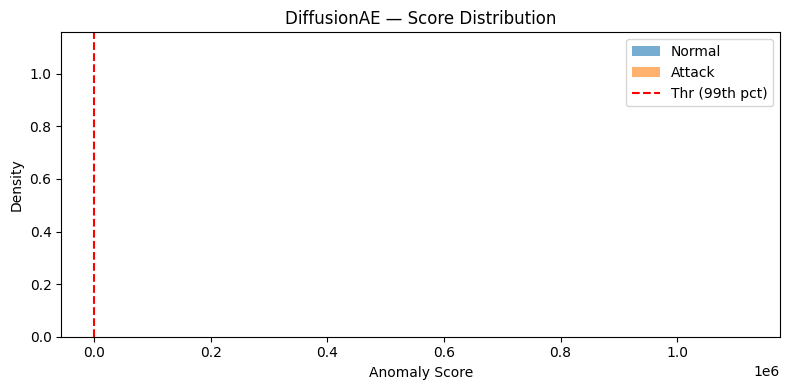


===== DiffusionAE Confusion Matrix (Sequence-Level) =====
TN=49  FP=13  FN=1  TP=295
Precision: 0.9578
Recall:    0.9966
F1:        0.9768


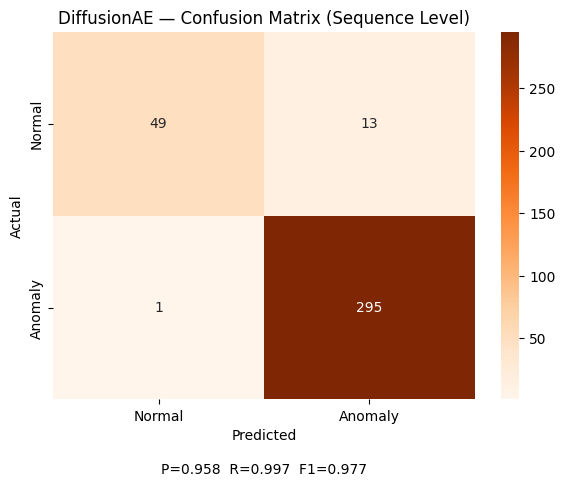

In [14]:
# --- Evaluate DiffusionAE ---
dae_scores_tr = diffusion_ae_score_sequences(dae_autoencoder, dae_diffusion, Xtr_all[normal_mask], schedule_dae, M=M_SCORE)
dae_scores_te = diffusion_ae_score_sequences(dae_autoencoder, dae_diffusion, Xte_all, schedule_dae, M=M_SCORE)

dae_metrics = compute_metrics_auto_thr(yte_seq, dae_scores_te, dae_scores_tr, thr_pct=THR_PCT)
print("DiffusionAE metrics:", {k: f"{v:.4f}" for k, v in dae_metrics.items()})

# Per-attack one-vs-normal breakdown
dae_thr = np.percentile(dae_scores_tr, THR_PCT)
pa_rows_dae = []
for atk in attacks:
    mask = (ate_seq == atk) | (ate_seq == "normal")
    y_sub = (ate_seq[mask] != "normal").astype(int)
    s_sub = dae_scores_te[mask]
    y_pred_sub = (s_sub >= dae_thr).astype(int)
    cm_sub = confusion_matrix(y_sub, y_pred_sub, labels=[0, 1])
    tn, fp, fn, tp = cm_sub.ravel()
    pa_rows_dae.append({
        "attack_type": atk,
        "n_attack_seqs": int((ate_seq[mask] == atk).sum()),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "precision": precision_score(y_sub, y_pred_sub, zero_division=0),
        "recall": recall_score(y_sub, y_pred_sub, zero_division=0),
        "f1": f1_score(y_sub, y_pred_sub, zero_division=0),
        "roc_auc": roc_auc_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
    })
print("\nPer-attack breakdown:")
display(pd.DataFrame(pa_rows_dae).sort_values("pr_auc", ascending=False).round(4))

# Score distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dae_scores_te[yte_seq == 0], bins=50, alpha=0.6, label="Normal", density=True)
ax.hist(dae_scores_te[yte_seq == 1], bins=50, alpha=0.6, label="Attack", density=True)
ax.axvline(dae_thr, color="red", linestyle="--", label=f"Thr ({THR_PCT}th pct)")
ax.set_title("DiffusionAE — Score Distribution")
ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Density"); ax.legend()
plt.tight_layout(); plt.show()

# Confusion matrix
y_pred_dae = (dae_scores_te >= dae_thr).astype(int)
cm = confusion_matrix(yte_seq, y_pred_dae)
tn, fp, fn, tp = cm.ravel()
print(f"\n===== DiffusionAE Confusion Matrix (Sequence-Level) =====")
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Precision: {precision_score(yte_seq, y_pred_dae):.4f}")
print(f"Recall:    {recall_score(yte_seq, y_pred_dae):.4f}")
print(f"F1:        {f1_score(yte_seq, y_pred_dae):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"], ax=ax)
ax.set_title("DiffusionAE — Confusion Matrix (Sequence Level)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.text(0.5, -0.2, f"P={precision_score(yte_seq, y_pred_dae):.3f}  R={recall_score(yte_seq, y_pred_dae):.3f}  F1={f1_score(yte_seq, y_pred_dae):.3f}",
        transform=ax.transAxes, ha="center", fontsize=10)
plt.tight_layout(); plt.show()

## 6. ImDiffusion — Imputed Diffusion Models for MTS Anomaly Detection

**Reference:** Chen, Y., Zhang, C., Ma, M., et al. (2023). *ImDiffusion: Imputed Diffusion Models for Multivariate Time Series Anomaly Detection.* Microsoft Research.

**Core Idea:** Combines time series **imputation** with diffusion models. Instead of reconstructing the full sequence, random time points are masked and imputed via a conditional diffusion process. The imputation error serves as the anomaly signal.

**Architecture:**
- Random masking strategy: at each inference pass, a fraction of time points are masked
- Conditional diffusion model imputes masked points given observed points
- **Multi-pass scoring**: run multiple imputation passes with different masks, aggregate errors

**Anomaly Score:** For each time point $c_i$:
$$AS(c_i) = \frac{1}{K} \sum_{k=1}^{K} \|c_i - \hat{c}_i^{(k)}\|^2$$
where $\hat{c}_i^{(k)}$ is the imputed value from the $k$-th mask pattern. Additionally, the paper leverages **intermediate denoised outputs** at different diffusion steps as multi-scale anomaly signals.

**Key Insight:** Imputation-based approaches use neighboring values for estimation, capturing both temporal and inter-correlated dependencies. This is more robust than full reconstruction because anomalous points do not contaminate the conditioning set.

In [15]:
# =============================================
# ImDiffusion Model — Conditional Imputation Denoiser
# =============================================
# The denoiser is conditioned on observed values via concatenation:
# input to network = [noisy_x, mask, observed_x] along channel dim.
# This follows the CSDI-style conditioning used in ImDiffusion.

class ConditionalUNet1D(nn.Module):
    """
    1D U-Net conditioned on observed values and a binary mask.
    Input: (B, D*3, T) — concat of [noisy, mask, observed] along channels.
    Output: (B, D, T) — predicted noise for masked positions.
    """
    def __init__(self, d_feat, base_ch=64, ch_mults=(1, 2, 4), time_dim=128):
        super().__init__()
        # Input has 3x channels: noisy + mask + observed
        self.unet = UNet1D(in_channels=d_feat * 3, base_ch=base_ch,
                           ch_mults=ch_mults, time_dim=time_dim)
        # Project back to d_feat channels
        self.out_proj = nn.Conv1d(d_feat * 3, d_feat, 1)

    def forward(self, x_noisy, t, mask, x_observed):
        """
        x_noisy:    (B, D, T) noisy sequence
        t:          (B,) timestep
        mask:       (B, D, T) binary mask (1=observed, 0=masked)
        x_observed: (B, D, T) observed values (0 where masked)
        """
        cond_input = torch.cat([x_noisy, mask, x_observed], dim=1)  # (B, 3D, T)
        out = self.unet(cond_input, t)  # (B, 3D, T)
        return self.out_proj(out)        # (B, D, T)


# =============================================
# ImDiffusion Training & Scoring
# =============================================

def train_imdiffusion(X_train, schedule, model, *, mask_ratio=0.2,
                      epochs=100, batch_size=256, lr=1e-4, seed=42):
    """
    Train ImDiffusion: at each step, randomly mask a fraction of time points
    and train the conditional denoiser to predict noise for masked positions.
    """
    set_seed(seed)
    X_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1).to(device)  # (N, D, T)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for (x0_batch,) in loader:
            B, D, T = x0_batch.shape

            # Random temporal mask: mask_ratio of time points are masked (all features)
            mask = torch.ones(B, 1, T, device=device)
            n_mask = int(T * mask_ratio)
            for b in range(B):
                idx = torch.randperm(T, device=device)[:n_mask]
                mask[b, :, idx] = 0.0
            mask = mask.expand(B, D, T)  # (B, D, T)

            x_observed = x0_batch * mask  # zero out masked positions

            # Forward diffusion on the FULL sequence
            n = torch.randint(0, schedule.T, (B,), device=device)
            noise = torch.randn_like(x0_batch)
            x_noisy = q_sample(x0_batch, n, schedule, noise)

            # Predict noise conditioned on mask and observed values
            pred_noise = model(x_noisy, n, mask, x_observed)

            # Loss only on masked positions (imputation objective)
            loss = F.mse_loss(pred_noise * (1 - mask), noise * (1 - mask))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * B

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs}  loss={total_loss/len(X_t):.6f}")


@torch.no_grad()
def imdiffusion_score_sequences(model, X, schedule, *, M=50, mask_ratio=0.2,
                                 n_passes=5, seed=0):
    """
    Multi-pass imputation scoring (ImDiffusion):
    For each pass, create a different random mask, impute, compute error.
    Final score = mean error across passes.
    Also collects intermediate denoised outputs for multi-scale signals.
    """
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1).to(device)  # (N, D, T)
    N, D, T = X_t.shape
    all_scores = np.zeros(N)

    for p in range(n_passes):
        rng = np.random.RandomState(seed + p)
        pass_scores = []

        for i in range(0, N, 256):
            batch = X_t[i:i+256]
            B = batch.size(0)

            # Create random mask for this pass
            mask = torch.ones(B, D, T, device=device)
            n_mask = int(T * mask_ratio)
            for b in range(B):
                idx = torch.from_numpy(rng.choice(T, n_mask, replace=False)).to(device)
                mask[b, :, idx] = 0.0

            x_observed = batch * mask

            # Start from noise and denoise conditioned on observed values
            x = torch.randn_like(batch)
            for step in reversed(range(M)):
                t = torch.full((B,), step, device=device, dtype=torch.long)
                pred_noise = model(x, t, mask, x_observed)
                # Standard reverse step using predicted noise
                betas = schedule.betas[t].view(-1, 1, 1)
                sqrt_omab = schedule.sqrt_one_minus_alphas_bar[t].view(-1, 1, 1)
                sqrt_recip_a = (1.0 / torch.sqrt(schedule.alphas[t])).view(-1, 1, 1)
                mean = sqrt_recip_a * (x - betas / sqrt_omab * pred_noise)
                if step > 0:
                    sigma = torch.sqrt(schedule.posterior_var[t]).view(-1, 1, 1)
                    x = mean + sigma * torch.randn_like(x)
                else:
                    x = mean
                # Replace observed positions with noised original at this step
                if step > 0:
                    t_s = torch.full((B,), step - 1, device=device, dtype=torch.long)
                    noised_obs = q_sample(batch, t_s, schedule)
                    x = mask * noised_obs + (1 - mask) * x

            # Imputation error at masked positions
            err = ((batch - x) * (1 - mask)).pow(2).sum(dim=(1, 2)) / ((1 - mask).sum(dim=(1, 2)) + 1e-8)
            pass_scores.append(err.cpu().numpy())

        all_scores += np.concatenate(pass_scores)

    return all_scores / n_passes


# --- Train ImDiffusion ---
print("Training ImDiffusion model...")
schedule_imd = DiffusionSchedule(N_DIFF_STEPS, schedule="linear",
                                  beta_start=BETA_START, beta_end=BETA_END).to(device)
imdiff_model = ConditionalUNet1D(D_feat, base_ch=64, ch_mults=(1, 2, 4)).to(device)
print(f"  Model params: {model_size_stats(imdiff_model)}")
train_imdiffusion(Xtr_normal, schedule_imd, imdiff_model, mask_ratio=0.2,
                  epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, seed=SEED)

Training ImDiffusion model...
  Model params: {'Params': 2682045, 'Size (MB)': 10.231189727783203}
  Epoch 20/100  loss=0.196901
  Epoch 40/100  loss=0.193184
  Epoch 60/100  loss=0.187901
  Epoch 80/100  loss=0.180662
  Epoch 100/100  loss=0.166945


ImDiffusion metrics: {'roc_auc': '0.9725', 'pr_auc': '0.9917', 'f1': '0.9750', 'precision': '0.9637', 'recall': '0.9865', 'accuracy': '0.9581'}

Per-attack breakdown:


,attack_type,n_attack_seqs,TN,FP,FN,TP,precision,recall,f1,roc_auc,pr_auc
4,P_I,30,51,11,0,30,0.7317,1.0000,0.8451,1.0000,1.0000
3,M_F,58,51,11,0,58,0.8406,1.0000,0.9134,0.9969,0.9973
2,F_I,60,51,11,0,60,0.8451,1.0000,0.9160,0.9758,0.9409
1,C_R,81,51,11,0,81,0.8804,1.0000,0.9364,0.9598,0.9059
0,C_D,67,51,11,4,63,0.8514,0.9403,0.8936,0.9514,0.9051


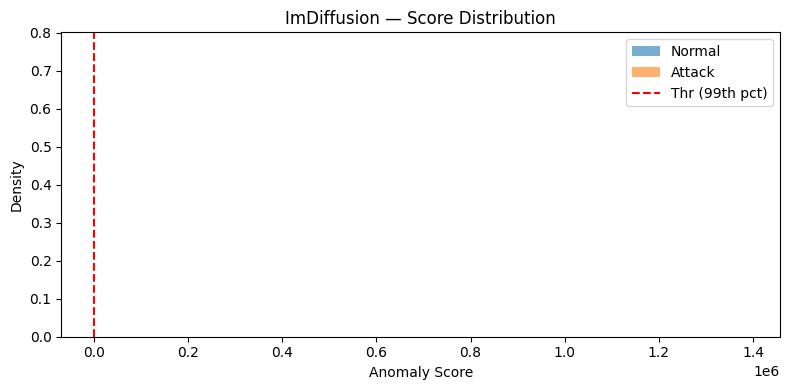


===== ImDiffusion Confusion Matrix (Sequence-Level) =====
TN=51  FP=11  FN=4  TP=292
Precision: 0.9637
Recall:    0.9865
F1:        0.9750


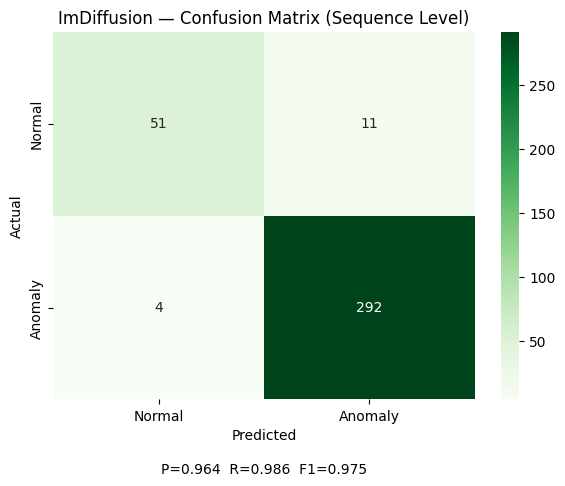

In [16]:
# --- Evaluate ImDiffusion ---
imd_scores_tr = imdiffusion_score_sequences(imdiff_model, Xtr_all[normal_mask], schedule_imd,
                                             M=M_SCORE, mask_ratio=0.2, n_passes=5, seed=SEED)
imd_scores_te = imdiffusion_score_sequences(imdiff_model, Xte_all, schedule_imd,
                                             M=M_SCORE, mask_ratio=0.2, n_passes=5, seed=SEED)

imd_metrics = compute_metrics_auto_thr(yte_seq, imd_scores_te, imd_scores_tr, thr_pct=THR_PCT)
print("ImDiffusion metrics:", {k: f"{v:.4f}" for k, v in imd_metrics.items()})

# Per-attack one-vs-normal breakdown (with confusion matrix components)
imd_thr = np.percentile(imd_scores_tr, THR_PCT)
attacks = sorted([a for a in np.unique(ate_seq) if a != "normal"])
pa_rows_imd = []
for atk in attacks:
    mask = (ate_seq == atk) | (ate_seq == "normal")
    y_sub = (ate_seq[mask] != "normal").astype(int)
    s_sub = imd_scores_te[mask]
    y_pred_sub = (s_sub >= imd_thr).astype(int)
    cm_sub = confusion_matrix(y_sub, y_pred_sub, labels=[0, 1])
    tn, fp, fn, tp = cm_sub.ravel()
    pa_rows_imd.append({
        "attack_type": atk,
        "n_attack_seqs": int((ate_seq[mask] == atk).sum()),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "precision": precision_score(y_sub, y_pred_sub, zero_division=0),
        "recall": recall_score(y_sub, y_pred_sub, zero_division=0),
        "f1": f1_score(y_sub, y_pred_sub, zero_division=0),
        "roc_auc": roc_auc_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
    })
print("\nPer-attack breakdown:")
display(pd.DataFrame(pa_rows_imd).sort_values("pr_auc", ascending=False).round(4))

# Score distribution
fig, ax = plt.subplots(figsize=(8, 4))
normal_s = imd_scores_te[yte_seq == 0]
attack_s = imd_scores_te[yte_seq == 1]
ax.hist(normal_s, bins=50, alpha=0.6, label="Normal", density=True)
ax.hist(attack_s, bins=50, alpha=0.6, label="Attack", density=True)
ax.axvline(imd_thr, color="red", linestyle="--", label=f"Thr ({THR_PCT}th pct)")
ax.set_title("ImDiffusion — Score Distribution")
ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Density"); ax.legend()
plt.tight_layout(); plt.show()

# Confusion matrix with printed metrics
y_pred_imd = (imd_scores_te >= imd_thr).astype(int)
cm = confusion_matrix(yte_seq, y_pred_imd)
tn, fp, fn, tp = cm.ravel()
print(f"\n===== ImDiffusion Confusion Matrix (Sequence-Level) =====")
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Precision: {precision_score(yte_seq, y_pred_imd):.4f}")
print(f"Recall:    {recall_score(yte_seq, y_pred_imd):.4f}")
print(f"F1:        {f1_score(yte_seq, y_pred_imd):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"], ax=ax)
ax.set_title("ImDiffusion — Confusion Matrix (Sequence Level)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.text(0.5, -0.2, f"P={precision_score(yte_seq, y_pred_imd):.3f}  R={recall_score(yte_seq, y_pred_imd):.3f}  F1={f1_score(yte_seq, y_pred_imd):.3f}",
        transform=ax.transAxes, ha="center", fontsize=10)
plt.tight_layout(); plt.show()

## 7. DiffAD — Imputation-based AD with Conditional Weight-Incremental Diffusion

**Reference:** Xiao, C., Gou, Z., Tai, W., Zhang, K., & Zhou, F. (2023). *Imputation-based Time-Series Anomaly Detection with Conditional Weight-Incremental Diffusion Models.* KDD 2023.

**Key Innovations:**
1. **Density ratio-based point selection:** Selects observed points that are likely normal by computing change scores between consecutive windows. Regions without change points → more points selected as observed.
2. **Conditional weight-incremental diffusion:** During reverse sampling, observed values are injected with an exponentially increasing weight $h(t-1) = N_0 e^{-\lambda(t-1)}$ so that as denoising progresses, generated values converge toward observed values.
3. **Multi-scale S4-based U-Net:** Uses structured state space (S4) layers to capture long-term temporal dependencies.

**Reverse step with weight-incremental conditioning (Eq. 11):**
$$x_{t-1} = s \odot \left[(1-h(t-1))\hat{x}_{t-1} + h(t-1)x_{ob}\right] + (1-s) \odot \hat{x}_{t-1}$$

**Anomaly Score:** Estimation error between real values and imputed values, averaged over masked points.

In [17]:
# =============================================
# DiffAD — S4-based Denoiser with Weight-Incremental Conditioning
# =============================================
# S4 layers are approximated here with a bidirectional GRU + linear SSM-style
# parameterization, since the full S4 implementation (HiPPO matrices) is complex.
# This captures the same long-range dependency modeling intent.

class S4Block(nn.Module):
    """Simplified S4-like block using bidirectional GRU for long-range dependencies."""
    def __init__(self, d_model):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.gru = nn.GRU(d_model, d_model, batch_first=True, bidirectional=True)
        self.proj = nn.Linear(d_model * 2, d_model)

    def forward(self, x):
        # x: (B, T, D)
        h, _ = self.gru(self.norm(x))
        return x + self.proj(h)


class MultiScaleS4UNet(nn.Module):
    """
    Multi-scale S4-based U-Net for DiffAD (paper Sec 3.2).
    Cascaded S4 layers with skip connections and dilated Conv1d.
    Conditioned on observed values, mask, and diffusion timestep.
    """
    def __init__(self, d_feat, n_layers=4, d_model=128, time_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
        )
        # Input projection: noisy + mask + observed → d_model
        self.in_proj = nn.Linear(d_feat * 3, d_model)

        # Cascaded S4 layers with dilated conv
        self.layers = nn.ModuleList()
        self.convs = nn.ModuleList()
        self.skips = nn.ModuleList()
        for i in range(n_layers):
            self.convs.append(nn.Sequential(
                nn.Conv1d(d_model, d_model, 3, padding=2**i, dilation=2**i),
                nn.SiLU(),
            ))
            self.layers.append(S4Block(d_model))
            self.skips.append(nn.Linear(d_model, d_model))

        self.out_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_feat),
        )

    def forward(self, x_noisy, t, mask, x_observed):
        """
        x_noisy/mask/x_observed: (B, D, T) each
        t: (B,) timestep
        Returns: (B, D, T) predicted noise
        """
        B, D, T = x_noisy.shape
        t_emb = self.time_mlp(t)  # (B, d_model)

        # Concat condition and project
        cond = torch.cat([x_noisy, mask, x_observed], dim=1)  # (B, 3D, T)
        h = self.in_proj(cond.permute(0, 2, 1))               # (B, T, d_model)
        h = h + t_emb.unsqueeze(1)                             # add time embedding

        # Cascaded S4 + Conv layers with skip connections
        skip_sum = torch.zeros_like(h)
        for conv, s4, skip_proj in zip(self.convs, self.layers, self.skips):
            h_conv = conv(h.permute(0, 2, 1)).permute(0, 2, 1)  # dilated conv
            h = s4(h + h_conv)                                    # S4 layer
            skip_sum = skip_sum + skip_proj(h)                    # skip connection

        out = self.out_proj(skip_sum)  # (B, T, D)
        return out.permute(0, 2, 1)    # (B, D, T)


# =============================================
# Density Ratio-based Point Selection (paper Sec 3.1)
# =============================================

def density_ratio_selection(X, window_size=10, obs_ratio=0.12, thr_pct=30):
    """
    Select observed points using change-score-based strategy (Eq. 1-2).
    Points in regions without change points are more likely normal → selected.
    Returns binary mask (B, T) where 1 = observed.
    """
    B, T, D = X.shape
    masks = np.ones((B, T))

    for b in range(B):
        seq = X[b]  # (T, D)
        # Compute change scores between consecutive windows
        n_windows = T // window_size
        change_scores = np.zeros(n_windows)
        for w in range(1, n_windows):
            w_prev = seq[(w-1)*window_size : w*window_size]
            w_curr = seq[w*window_size : (w+1)*window_size]
            # Simple density ratio approximation via L2 distance of means
            ratio = np.linalg.norm(w_prev.mean(0) - w_curr.mean(0))
            change_scores[w] = ratio

        # Threshold: windows with high change scores contain potential anomalies
        if n_windows > 1:
            thr = np.percentile(change_scores[1:], thr_pct)
        else:
            thr = 0.0

        # Build selection mask: more points from stable regions
        n_obs = int(T * obs_ratio)
        stable_indices = []
        for w in range(n_windows):
            if change_scores[w] <= thr:
                stable_indices.extend(range(w * window_size, min((w+1) * window_size, T)))

        if len(stable_indices) >= n_obs:
            selected = np.random.choice(stable_indices, n_obs, replace=False)
        else:
            # Fall back to all stable + random from rest
            remaining = list(set(range(T)) - set(stable_indices))
            extra = np.random.choice(remaining, min(n_obs - len(stable_indices), len(remaining)), replace=False)
            selected = np.concatenate([stable_indices, extra]).astype(int)

        mask = np.zeros(T)
        mask[selected] = 1.0
        masks[b] = mask

    return masks


# =============================================
# Weight-Incremental Reverse Sampling (Eq. 10-11)
# =============================================

def weight_incremental_h(t, T, N0=1.0, lam=0.05):
    """Exponential weight function h(t-1) = N0 * exp(-lambda * (t-1))."""
    return N0 * math.exp(-lam * (t))


@torch.no_grad()
def diffad_reverse_sample(model, x_obs, obs_mask, schedule, M=50, N0=1.0, lam=0.05):
    """
    Weight-incremental conditional reverse sampling (Eq. 9-11).
    obs_mask: (B, D, T) binary mask, x_obs: (B, D, T) observed values
    """
    B, D, T = x_obs.shape
    x = torch.randn(B, D, T, device=x_obs.device)

    for step in reversed(range(M)):
        t = torch.full((B,), step, device=x.device, dtype=torch.long)
        pred_noise = model(x, t, obs_mask, x_obs * obs_mask)

        # Standard reverse step (Eq. 9)
        betas = schedule.betas[t].view(-1, 1, 1)
        sqrt_omab = schedule.sqrt_one_minus_alphas_bar[t].view(-1, 1, 1)
        sqrt_recip_a = (1.0 / torch.sqrt(schedule.alphas[t])).view(-1, 1, 1)
        x_hat = sqrt_recip_a * (x - betas / sqrt_omab * pred_noise)
        if step > 0:
            sigma = torch.sqrt(schedule.posterior_var[t]).view(-1, 1, 1)
            x_hat = x_hat + sigma * torch.randn_like(x)

        # Weight-incremental conditioning (Eq. 11)
        h = weight_incremental_h(step, schedule.T, N0, lam)
        x = obs_mask * ((1 - h) * x_hat + h * x_obs) + (1 - obs_mask) * x_hat

    return x


# =============================================
# DiffAD Training & Scoring
# =============================================

def train_diffad(X_train, schedule, model, *, obs_ratio=0.12,
                 epochs=100, batch_size=256, lr=3e-4, seed=42):
    """Train DiffAD with density-ratio-based masking."""
    set_seed(seed)
    X_t = torch.tensor(X_train, dtype=torch.float32).to(device)  # (N, T, D)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for (x0_batch,) in loader:
            B, T, D = x0_batch.shape
            x0_cf = x0_batch.permute(0, 2, 1)  # (B, D, T)

            # Density-ratio selection for this batch
            sel_masks = density_ratio_selection(x0_batch.cpu().numpy(), obs_ratio=obs_ratio)
            obs_mask = torch.tensor(sel_masks, dtype=torch.float32, device=device)
            obs_mask = obs_mask.unsqueeze(1).expand(B, D, T)  # (B, D, T)
            x_obs = x0_cf * obs_mask

            # Forward diffusion + noise prediction
            n = torch.randint(0, schedule.T, (B,), device=device)
            noise = torch.randn_like(x0_cf)
            x_noisy = q_sample(x0_cf, n, schedule, noise)
            pred_noise = model(x_noisy, n, obs_mask, x_obs)

            # Loss on masked (imputed) positions
            loss = F.mse_loss(pred_noise * (1 - obs_mask), noise * (1 - obs_mask))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * B

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs}  loss={total_loss/len(X_t):.6f}")


@torch.no_grad()
def diffad_score_sequences(model, X, schedule, *, M=50, obs_ratio=0.12,
                            N0=1.0, lam=0.05, seed=0):
    """Score sequences using DiffAD weight-incremental imputation."""
    model.eval()
    X_np = X.copy()
    N, T, D = X_np.shape
    scores = []

    for i in range(0, N, 256):
        batch_np = X_np[i:i+256]
        B = batch_np.shape[0]
        batch = torch.tensor(batch_np, dtype=torch.float32, device=device)
        batch_cf = batch.permute(0, 2, 1)

        # Density-ratio selection
        sel_masks = density_ratio_selection(batch_np, obs_ratio=obs_ratio)
        obs_mask = torch.tensor(sel_masks, dtype=torch.float32, device=device)
        obs_mask = obs_mask.unsqueeze(1).expand(B, D, T)

        # Weight-incremental reverse sampling
        x_imputed = diffad_reverse_sample(model, batch_cf, obs_mask, schedule,
                                          M=M, N0=N0, lam=lam)

        # Anomaly score: error at masked positions
        err = ((batch_cf - x_imputed) * (1 - obs_mask)).pow(2)
        err = err.sum(dim=(1, 2)) / ((1 - obs_mask).sum(dim=(1, 2)) + 1e-8)
        scores.append(err.cpu().numpy())

    return np.concatenate(scores)


# --- Train DiffAD ---
print("Training DiffAD model...")
schedule_dad = DiffusionSchedule(N_DIFF_STEPS, schedule="linear",
                                  beta_start=BETA_START, beta_end=BETA_END).to(device)
diffad_model = MultiScaleS4UNet(D_feat, n_layers=4, d_model=128).to(device)
print(f"  Model params: {model_size_stats(diffad_model)}")
train_diffad(Xtr_normal, schedule_dad, diffad_model, obs_ratio=0.12,
             epochs=EPOCHS, batch_size=BATCH_SIZE, lr=3e-4, seed=SEED)

Training DiffAD model...
  Model params: {'Params': 1236493, 'Size (MB)': 4.716846466064453}
  Epoch 20/100  loss=0.640258
  Epoch 40/100  loss=0.445888
  Epoch 60/100  loss=0.367521
  Epoch 80/100  loss=0.288336
  Epoch 100/100  loss=0.257417


DiffAD metrics: {'roc_auc': '0.9759', 'pr_auc': '0.9919', 'f1': '0.9833', 'precision': '0.9704', 'recall': '0.9966', 'accuracy': '0.9721'}

Per-attack breakdown:


,attack_type,n_attack_seqs,TN,FP,FN,TP,precision,recall,f1,roc_auc,pr_auc
4,P_I,30,53,9,0,30,0.7692,1.0000,0.8696,1.0000,1.0000
3,M_F,58,53,9,0,58,0.8657,1.0000,0.9280,1.0000,1.0000
2,F_I,60,53,9,0,60,0.8696,1.0000,0.9302,0.9704,0.9284
1,C_R,81,53,9,0,81,0.9000,1.0000,0.9474,0.9677,0.9135
0,C_D,67,53,9,1,66,0.8800,0.9851,0.9296,0.9588,0.8956


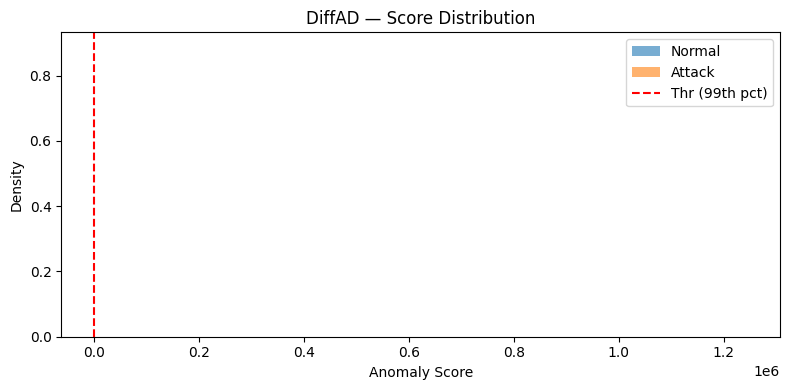


===== DiffAD Confusion Matrix (Sequence-Level) =====
TN=53  FP=9  FN=1  TP=295
Precision: 0.9704
Recall:    0.9966
F1:        0.9833


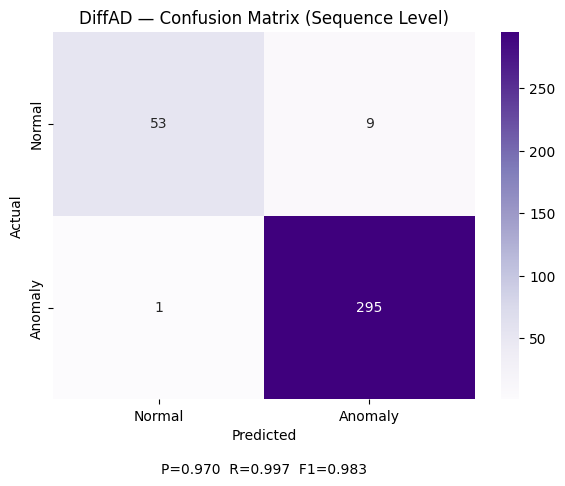

In [18]:
# --- Evaluate DiffAD ---
dad_scores_tr = diffad_score_sequences(diffad_model, Xtr_all[normal_mask], schedule_dad,
                                        M=M_SCORE, obs_ratio=0.12, seed=SEED)
dad_scores_te = diffad_score_sequences(diffad_model, Xte_all, schedule_dad,
                                        M=M_SCORE, obs_ratio=0.12, seed=SEED)

dad_metrics = compute_metrics_auto_thr(yte_seq, dad_scores_te, dad_scores_tr, thr_pct=THR_PCT)
print("DiffAD metrics:", {k: f"{v:.4f}" for k, v in dad_metrics.items()})

# Per-attack one-vs-normal breakdown (with confusion matrix components)
dad_thr = np.percentile(dad_scores_tr, THR_PCT)
attacks = sorted([a for a in np.unique(ate_seq) if a != "normal"])
pa_rows_dad = []
for atk in attacks:
    mask = (ate_seq == atk) | (ate_seq == "normal")
    y_sub = (ate_seq[mask] != "normal").astype(int)
    s_sub = dad_scores_te[mask]
    y_pred_sub = (s_sub >= dad_thr).astype(int)
    cm_sub = confusion_matrix(y_sub, y_pred_sub, labels=[0, 1])
    tn, fp, fn, tp = cm_sub.ravel()
    pa_rows_dad.append({
        "attack_type": atk,
        "n_attack_seqs": int((ate_seq[mask] == atk).sum()),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "precision": precision_score(y_sub, y_pred_sub, zero_division=0),
        "recall": recall_score(y_sub, y_pred_sub, zero_division=0),
        "f1": f1_score(y_sub, y_pred_sub, zero_division=0),
        "roc_auc": roc_auc_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
    })
print("\nPer-attack breakdown:")
display(pd.DataFrame(pa_rows_dad).sort_values("pr_auc", ascending=False).round(4))

# Score distribution
fig, ax = plt.subplots(figsize=(8, 4))
normal_s = dad_scores_te[yte_seq == 0]
attack_s = dad_scores_te[yte_seq == 1]
ax.hist(normal_s, bins=50, alpha=0.6, label="Normal", density=True)
ax.hist(attack_s, bins=50, alpha=0.6, label="Attack", density=True)
ax.axvline(dad_thr, color="red", linestyle="--", label=f"Thr ({THR_PCT}th pct)")
ax.set_title("DiffAD — Score Distribution")
ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Density"); ax.legend()
plt.tight_layout(); plt.show()

# Confusion matrix with printed metrics
y_pred_dad = (dad_scores_te >= dad_thr).astype(int)
cm = confusion_matrix(yte_seq, y_pred_dad)
tn, fp, fn, tp = cm.ravel()
print(f"\n===== DiffAD Confusion Matrix (Sequence-Level) =====")
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Precision: {precision_score(yte_seq, y_pred_dad):.4f}")
print(f"Recall:    {recall_score(yte_seq, y_pred_dad):.4f}")
print(f"F1:        {f1_score(yte_seq, y_pred_dad):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"], ax=ax)
ax.set_title("DiffAD — Confusion Matrix (Sequence Level)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.text(0.5, -0.2, f"P={precision_score(yte_seq, y_pred_dad):.3f}  R={recall_score(yte_seq, y_pred_dad):.3f}  F1={f1_score(yte_seq, y_pred_dad):.3f}",
        transform=ax.transAxes, ha="center", fontsize=10)
plt.tight_layout(); plt.show()

## 8. DiffADT — Unsupervised Diffusion-based Anomaly Detection with S4 + Entity Embedding

**Reference:** Zuo, H., Zhu, A., Zhu, Y., Liao, Y., Li, S., & Chen, Y. (2024). *Unsupervised diffusion based anomaly detection for time series.* Applied Intelligence.

**Core Idea:** Reconstruction-based DDPM with three key enhancements:
1. **S4 (Structured State Space) layers** replace dilated convolutions for long-term dependency capture
2. **Entity-ID embedding** distinguishes different time series patterns (sensor types, collection contexts)
3. **Cascaded architecture** with skip connections across S4 layers

**Architecture (Fig. 1 in paper):**
- Cascaded S4 layers with bidirectional dilated Conv1D for local features
- Condition = [original time series curve, control signals, entity ID]
- Skip connections from each S4 layer are summed → Conv1D → output

**Anomaly Scoring (Eq. 5):** Smoothed convolutional distance between original and reconstructed signals:
$$\text{distance}(x_i) = \int_{i-w}^{i+w} c(i-t) \cdot \|x_t - p(q(x_t))\|_{L1} \, dt$$

**Detection:** Three-sigma rule on distance distribution: $P(\mu - 3\sigma, \mu + 3\sigma)$ covers 99.73% of normal data.

In [19]:
# =============================================
# DiffADT — Cascaded S4 Denoiser with Entity Embedding
# =============================================
# Follows the architecture in Fig. 1 of Zuo et al.
# For the automotive ethernet dataset, entity_id can represent
# different traffic pattern types or be set to 0 for a single entity.

class DiffADTLayer(nn.Module):
    """
    Single cascaded layer (Fig. 1 left): bidirectional dilated Conv1D → S4 block.
    Produces a skip output and a forward output for the next layer.
    """
    def __init__(self, d_model, dilation=1):
        super().__init__()
        # Bidirectional dilated Conv1D for local temporal features
        self.conv = nn.Sequential(
            nn.Conv1d(d_model, d_model, 3, padding=dilation, dilation=dilation),
            nn.SiLU(),
            nn.Conv1d(d_model, d_model, 3, padding=dilation, dilation=dilation),
            nn.SiLU(),
        )
        # S4-like block for long-range dependencies
        self.s4 = S4Block(d_model)
        # Skip projection
        self.skip_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        # x: (B, T, d_model)
        h = self.conv(x.permute(0, 2, 1)).permute(0, 2, 1)  # local features
        h = self.s4(x + h)                                    # long-range features
        skip = self.skip_proj(h)
        return h, skip  # forward output, skip output


class DiffADTNet(nn.Module):
    """
    Full DiffADT denoiser (Fig. 1 right):
    - Input: noisy x_t + diffusion step t + condition (original curve + entity ID)
    - Cascaded DiffADT layers with skip connections
    - Output: predicted noise
    """
    def __init__(self, d_feat, n_layers=6, d_model=128, time_dim=64, n_entities=1):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
        )
        # Entity embedding (paper innovation #2)
        self.entity_emb = nn.Embedding(n_entities, d_model)
        # Input: noisy signal + condition (original curve)
        self.in_proj = nn.Linear(d_feat * 2, d_model)

        # Cascaded layers with increasing dilation
        self.layers = nn.ModuleList([
            DiffADTLayer(d_model, dilation=2**i) for i in range(n_layers)
        ])

        # Output projection: aggregate skip connections → Conv1D → output
        self.out_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_feat),
        )

    def forward(self, x_noisy, t, x_cond, entity_ids=None):
        """
        x_noisy: (B, D, T) noisy input
        t: (B,) timestep
        x_cond: (B, D, T) original (condition) signal
        entity_ids: (B,) integer entity IDs (optional)
        """
        B, D, T = x_noisy.shape
        t_emb = self.time_mlp(t)  # (B, d_model)

        # Concatenate noisy + condition along channel dim, then project
        inp = torch.cat([x_noisy, x_cond], dim=1)  # (B, 2D, T)
        h = self.in_proj(inp.permute(0, 2, 1))      # (B, T, d_model)

        # Add time embedding + entity embedding
        h = h + t_emb.unsqueeze(1)
        if entity_ids is not None:
            e_emb = self.entity_emb(entity_ids)      # (B, d_model)
            h = h + e_emb.unsqueeze(1)

        # Cascaded layers
        skip_sum = torch.zeros_like(h)
        for layer in self.layers:
            h, skip = layer(h)
            skip_sum = skip_sum + skip

        # Output
        out = self.out_proj(skip_sum)  # (B, T, D)
        return out.permute(0, 2, 1)     # (B, D, T)


# =============================================
# DiffADT Training & Scoring
# =============================================

def train_diffadt(X_train, schedule, model, *, epochs=100, batch_size=256, lr=1e-3, seed=42):
    """
    Train DiffADT: standard DDPM training with original signal as condition.
    Uses warmup learning rate schedule (paper Sec 4.2).
    """
    set_seed(seed)
    X_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1).to(device)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=True)
    optimizer = optim.AdamW(model.parameters(), lr=lr)

    # Warmup schedule: rise for first 1/4 epochs, then cosine decay
    warmup_epochs = epochs // 4
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs
        return 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (epochs - warmup_epochs)))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for (x0_batch,) in loader:
            n = torch.randint(0, schedule.T, (x0_batch.size(0),), device=device)
            noise = torch.randn_like(x0_batch)
            x_noisy = q_sample(x0_batch, n, schedule, noise)
            # Condition = original (clean) signal
            pred_noise = model(x_noisy, n, x0_batch, entity_ids=None)
            loss = F.mse_loss(pred_noise, noise)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x0_batch.size(0)
        scheduler.step()

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs}  loss={total_loss/len(X_t):.6f}  lr={scheduler.get_last_lr()[0]:.6f}")


@torch.no_grad()
def diffadt_score_sequences(model, X, schedule, M=20, conv_window=5):
    """
    Score sequences using DiffADT reconstruction + smoothed distance (Eq. 5).
    Uses fewer sampling steps (paper uses step=20 for efficiency).
    """
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1).to(device)
    scores = []

    for i in range(0, len(X_t), 256):
        batch = X_t[i:i+256]
        B = batch.size(0)

        # Forward: add noise at level M
        t_M = torch.full((B,), M - 1, device=device, dtype=torch.long)
        x = q_sample(batch, t_M, schedule)

        # Reverse: denoise M steps with original as condition
        for step in reversed(range(M)):
            t = torch.full((B,), step, device=device, dtype=torch.long)
            pred_noise = model(x, t, batch, entity_ids=None)
            betas = schedule.betas[t].view(-1, 1, 1)
            sqrt_omab = schedule.sqrt_one_minus_alphas_bar[t].view(-1, 1, 1)
            sqrt_recip_a = (1.0 / torch.sqrt(schedule.alphas[t])).view(-1, 1, 1)
            mean = sqrt_recip_a * (x - betas / sqrt_omab * pred_noise)
            if step > 0:
                sigma = torch.sqrt(schedule.posterior_var[t]).view(-1, 1, 1)
                x = mean + sigma * torch.randn_like(x)
            else:
                x = mean

        # Smoothed L1 distance (Eq. 5) — convolve pointwise distance
        pointwise_dist = (batch - x).abs().mean(dim=1)  # (B, T)
        kernel = torch.ones(1, 1, conv_window, device=device) / conv_window
        smoothed = F.conv1d(pointwise_dist.unsqueeze(1), kernel, padding=conv_window//2).squeeze(1)
        scores.append(smoothed.mean(dim=1).cpu().numpy())  # mean over time

    return np.concatenate(scores)


# --- Train DiffADT ---
print("Training DiffADT model...")
schedule_adt = DiffusionSchedule(200, schedule="linear",
                                  beta_start=BETA_START, beta_end=BETA_END).to(device)
diffadt_model = DiffADTNet(D_feat, n_layers=6, d_model=128, n_entities=1).to(device)
print(f"  Model params: {model_size_stats(diffadt_model)}")
train_diffadt(Xtr_normal, schedule_adt, diffadt_model,
              epochs=EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, seed=SEED)

Training DiffADT model...
  Model params: {'Params': 2124813, 'Size (MB)': 8.105518341064453}
  Epoch 20/100  loss=0.590759  lr=0.000800
  Epoch 40/100  loss=0.203712  lr=0.000905
  Epoch 60/100  loss=0.140555  lr=0.000552
  Epoch 80/100  loss=0.096384  lr=0.000165
  Epoch 100/100  loss=0.084069  lr=0.000000


DiffADT metrics: {'roc_auc': '0.9896', 'pr_auc': '0.9978', 'f1': '0.9094', 'precision': '0.8338', 'recall': '1.0000', 'accuracy': '0.8352'}

Per-attack breakdown:


,attack_type,n_attack_seqs,TN,FP,FN,TP,precision,recall,f1,roc_auc,pr_auc
4,P_I,30,3,59,0,30,0.3371,1.0,0.5042,1.0000,1.0000
3,M_F,58,3,59,0,58,0.4957,1.0,0.6629,1.0000,1.0000
2,F_I,60,3,59,0,60,0.5042,1.0,0.6704,0.9938,0.9928
1,C_R,81,3,59,0,81,0.5786,1.0,0.7330,0.9902,0.9909
0,C_D,67,3,59,0,67,0.5317,1.0,0.6943,0.9716,0.9789


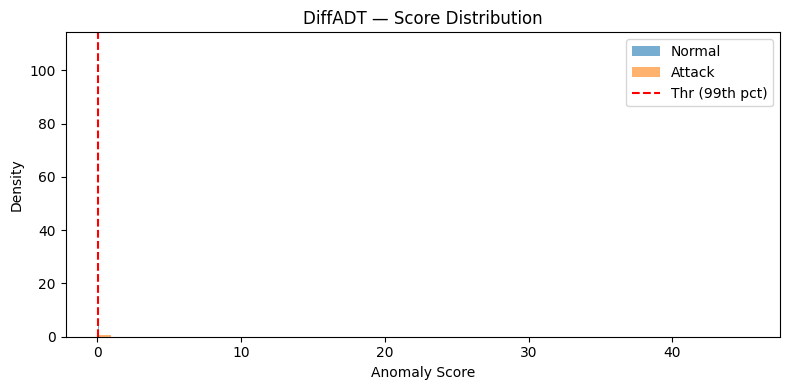


===== DiffADT Confusion Matrix (Sequence-Level) =====
TN=3  FP=59  FN=0  TP=296
Precision: 0.8338
Recall:    1.0000
F1:        0.9094


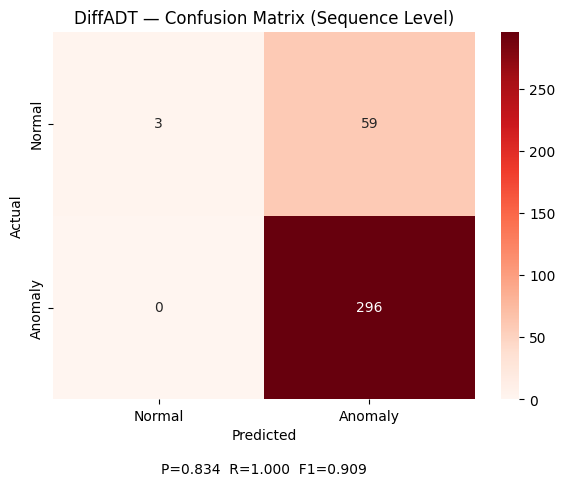

In [20]:
# --- Evaluate DiffADT ---
adt_scores_tr = diffadt_score_sequences(diffadt_model, Xtr_all[normal_mask], schedule_adt, M=20)
adt_scores_te = diffadt_score_sequences(diffadt_model, Xte_all, schedule_adt, M=20)

adt_metrics = compute_metrics_auto_thr(yte_seq, adt_scores_te, adt_scores_tr, thr_pct=THR_PCT)
print("DiffADT metrics:", {k: f"{v:.4f}" for k, v in adt_metrics.items()})

# Per-attack one-vs-normal breakdown (with confusion matrix components)
adt_thr = np.percentile(adt_scores_tr, THR_PCT)
attacks = sorted([a for a in np.unique(ate_seq) if a != "normal"])
pa_rows_adt = []
for atk in attacks:
    mask = (ate_seq == atk) | (ate_seq == "normal")
    y_sub = (ate_seq[mask] != "normal").astype(int)
    s_sub = adt_scores_te[mask]
    y_pred_sub = (s_sub >= adt_thr).astype(int)
    cm_sub = confusion_matrix(y_sub, y_pred_sub, labels=[0, 1])
    tn, fp, fn, tp = cm_sub.ravel()
    pa_rows_adt.append({
        "attack_type": atk,
        "n_attack_seqs": int((ate_seq[mask] == atk).sum()),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "precision": precision_score(y_sub, y_pred_sub, zero_division=0),
        "recall": recall_score(y_sub, y_pred_sub, zero_division=0),
        "f1": f1_score(y_sub, y_pred_sub, zero_division=0),
        "roc_auc": roc_auc_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
    })
print("\nPer-attack breakdown:")
display(pd.DataFrame(pa_rows_adt).sort_values("pr_auc", ascending=False).round(4))

# Score distribution
fig, ax = plt.subplots(figsize=(8, 4))
normal_s = adt_scores_te[yte_seq == 0]
attack_s = adt_scores_te[yte_seq == 1]
ax.hist(normal_s, bins=50, alpha=0.6, label="Normal", density=True)
ax.hist(attack_s, bins=50, alpha=0.6, label="Attack", density=True)
ax.axvline(adt_thr, color="red", linestyle="--", label=f"Thr ({THR_PCT}th pct)")
ax.set_title("DiffADT — Score Distribution")
ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Density"); ax.legend()
plt.tight_layout(); plt.show()

# Confusion matrix with printed metrics
y_pred_adt = (adt_scores_te >= adt_thr).astype(int)
cm = confusion_matrix(yte_seq, y_pred_adt)
tn, fp, fn, tp = cm.ravel()
print(f"\n===== DiffADT Confusion Matrix (Sequence-Level) =====")
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Precision: {precision_score(yte_seq, y_pred_adt):.4f}")
print(f"Recall:    {recall_score(yte_seq, y_pred_adt):.4f}")
print(f"F1:        {f1_score(yte_seq, y_pred_adt):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"], ax=ax)
ax.set_title("DiffADT — Confusion Matrix (Sequence Level)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.text(0.5, -0.2, f"P={precision_score(yte_seq, y_pred_adt):.3f}  R={recall_score(yte_seq, y_pred_adt):.3f}  F1={f1_score(yte_seq, y_pred_adt):.3f}",
        transform=ax.transAxes, ha="center", fontsize=10)
plt.tight_layout(); plt.show()

## 9. TimeGrad — Autoregressive Denoising Diffusion for Forecasting-based AD

**Reference:** Rasul, K., Seward, C., Schuster, I., & Vollgraf, R. (2021). *Autoregressive Denoising Diffusion Models for Multivariate Probabilistic Time Series Forecasting.* ICML 2021.

**Core Idea:** An **autoregressive** forecasting model that uses diffusion to model the conditional distribution at each time step. For anomaly detection, we use **forecasting error** as the anomaly signal.

**Architecture:**
- **RNN (GRU)** processes the time series autoregressively, maintaining a hidden state $h_t$
- At each step, a **conditional DDPM** generates $x_t$ given $h_t$ by denoising from Gaussian noise
- The diffusion model $\epsilon_\theta(x_t^{(n)}, h_t, n)$ is conditioned on the RNN hidden state

**Training:** Teacher forcing — at each timestep, feed the true $x_{t-1}$ and predict noise for $x_t$:
$$\mathcal{L} = \sum_t \mathbb{E}_{n, \epsilon} \|\epsilon - \epsilon_\theta(\sqrt{\bar{\alpha}_n} x_t + \sqrt{1-\bar{\alpha}_n}\epsilon,\; h_t,\; n)\|^2$$

**Anomaly Scoring:** For each test timestep:
1. Generate forecast $\hat{x}_t$ via full reverse diffusion conditioned on $h_t$
2. Anomaly score $= \|x_t - \hat{x}_t\|^2$

In [21]:
# =============================================
# TimeGrad — RNN + Conditional Diffusion (Rasul et al.)
# =============================================

class TimeGradEpsilon(nn.Module):
    """
    Noise prediction network conditioned on RNN hidden state.
    Input: noisy x_t (D,), hidden state h_t (hidden_dim,), timestep n
    Output: predicted noise (D,)
    """
    def __init__(self, d_feat, hidden_dim, time_dim=64):
        super().__init__()
        self.time_emb = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
        )
        # MLP: concat(noisy_x, h, time_emb) → noise
        input_dim = d_feat + hidden_dim + time_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, d_feat),
        )

    def forward(self, x_noisy, h, t):
        """
        x_noisy: (B, D) noisy observation
        h: (B, hidden_dim) RNN hidden state
        t: (B,) timestep
        """
        t_emb = self.time_emb(t)  # (B, time_dim)
        inp = torch.cat([x_noisy, h, t_emb], dim=1)
        return self.net(inp)


class TimeGrad(nn.Module):
    """
    Full TimeGrad model: GRU encoder + conditional diffusion.
    """
    def __init__(self, d_feat, hidden_dim=128, n_layers=2, time_dim=64):
        super().__init__()
        self.rnn = nn.GRU(d_feat, hidden_dim, n_layers, batch_first=True)
        self.eps_net = TimeGradEpsilon(d_feat, hidden_dim, time_dim)
        self.hidden_dim = hidden_dim

    def get_hidden_states(self, x):
        """Run RNN over sequence, return hidden states at each step."""
        # x: (B, T, D) → h: (B, T, hidden_dim)
        h, _ = self.rnn(x)
        return h


# =============================================
# TimeGrad Training (Teacher Forcing)
# =============================================

def train_timegrad(X_train, schedule, model, *, epochs=100, batch_size=256, lr=1e-4, seed=42):
    """
    Train TimeGrad with teacher forcing:
    At each timestep t, use h_t from true x_{0:t-1} to predict noise for x_t.
    """
    set_seed(seed)
    X_t = torch.tensor(X_train, dtype=torch.float32).to(device)  # (N, T, D)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for (x0_batch,) in loader:
            B, T, D = x0_batch.shape
            # Get RNN hidden states (teacher forcing: feed true sequence)
            h_states = model.get_hidden_states(x0_batch)  # (B, T, hidden)

            # For each timestep (predict x_t given h_{t-1})
            # Use h from previous step; for t=0 use zeros
            h_prev = torch.cat([
                torch.zeros(B, 1, model.hidden_dim, device=device),
                h_states[:, :-1, :]
            ], dim=1)  # (B, T, hidden)

            # Random diffusion timestep per sample
            n = torch.randint(0, schedule.T, (B,), device=device)
            noise = torch.randn_like(x0_batch)  # (B, T, D)

            # Apply noise to each x_t independently
            sqrt_ab = schedule.sqrt_alphas_bar[n].view(B, 1, 1)
            sqrt_omab = schedule.sqrt_one_minus_alphas_bar[n].view(B, 1, 1)
            x_noisy = sqrt_ab * x0_batch + sqrt_omab * noise  # (B, T, D)

            # Predict noise: flatten temporal dim for the epsilon net
            x_flat = x_noisy.reshape(B * T, D)
            h_flat = h_prev.reshape(B * T, model.hidden_dim)
            n_flat = n.unsqueeze(1).expand(B, T).reshape(B * T)

            pred = model.eps_net(x_flat, h_flat, n_flat)
            loss = F.mse_loss(pred, noise.reshape(B * T, D))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * B

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs}  loss={total_loss/len(X_t):.6f}")


@torch.no_grad()
def timegrad_score_sequences(model, X, schedule, M=20):
    """
    Score sequences: for each timestep, forecast via reverse diffusion,
    then compute per-step prediction error. Sequence score = mean error.
    """
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    scores = []

    for i in range(0, len(X_t), 128):
        batch = X_t[i:i+128]
        B, T, D = batch.shape

        # Get hidden states from true sequence (for conditioning)
        h_states = model.get_hidden_states(batch)
        h_prev = torch.cat([
            torch.zeros(B, 1, model.hidden_dim, device=device),
            h_states[:, :-1, :]
        ], dim=1)

        # For each timestep, generate forecast via reverse diffusion
        all_errors = torch.zeros(B, T, device=device)
        for t_step in range(T):
            h_t = h_prev[:, t_step, :]  # (B, hidden)
            # Start from noise
            x = torch.randn(B, D, device=device)
            for step in reversed(range(M)):
                n = torch.full((B,), step, device=device, dtype=torch.long)
                eps_pred = model.eps_net(x, h_t, n)
                betas = schedule.betas[n].view(-1, 1)
                sqrt_omab = schedule.sqrt_one_minus_alphas_bar[n].view(-1, 1)
                sqrt_recip_a = (1.0 / torch.sqrt(schedule.alphas[n])).view(-1, 1)
                mean = sqrt_recip_a * (x - betas / sqrt_omab * eps_pred)
                if step > 0:
                    sigma = torch.sqrt(schedule.posterior_var[n]).view(-1, 1)
                    x = mean + sigma * torch.randn_like(x)
                else:
                    x = mean

            # Prediction error at this timestep
            all_errors[:, t_step] = (batch[:, t_step, :] - x).pow(2).mean(dim=1)

        scores.append(all_errors.mean(dim=1).cpu().numpy())

    return np.concatenate(scores)


# --- Train TimeGrad ---
print("Training TimeGrad model...")
schedule_tg = DiffusionSchedule(N_DIFF_STEPS, schedule="linear",
                                 beta_start=BETA_START, beta_end=BETA_END).to(device)
timegrad_model = TimeGrad(D_feat, hidden_dim=128, n_layers=2).to(device)
print(f"  Model params: {model_size_stats(timegrad_model)}")
train_timegrad(Xtr_normal, schedule_tg, timegrad_model,
               epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, seed=SEED)

Training TimeGrad model...
  Model params: {'Params': 280013, 'Size (MB)': 1.0681648254394531}
  Epoch 20/100  loss=0.992137
  Epoch 40/100  loss=0.972533
  Epoch 60/100  loss=0.970153
  Epoch 80/100  loss=0.927204
  Epoch 100/100  loss=0.846647


TimeGrad metrics: {'roc_auc': '0.9740', 'pr_auc': '0.9918', 'f1': '0.9784', 'precision': '0.9609', 'recall': '0.9966', 'accuracy': '0.9637'}

Per-attack breakdown:


,attack_type,n_attack_seqs,TN,FP,FN,TP,precision,recall,f1,roc_auc,pr_auc
4,P_I,30,50,12,0,30,0.7143,1.0000,0.8333,1.0000,1.0000
3,M_F,58,50,12,0,58,0.8286,1.0000,0.9062,1.0000,1.0000
2,F_I,60,50,12,0,60,0.8333,1.0000,0.9091,0.9742,0.9432
1,C_R,81,50,12,0,81,0.8710,1.0000,0.9310,0.9610,0.9074
0,C_D,67,50,12,1,66,0.8462,0.9851,0.9103,0.9555,0.8929


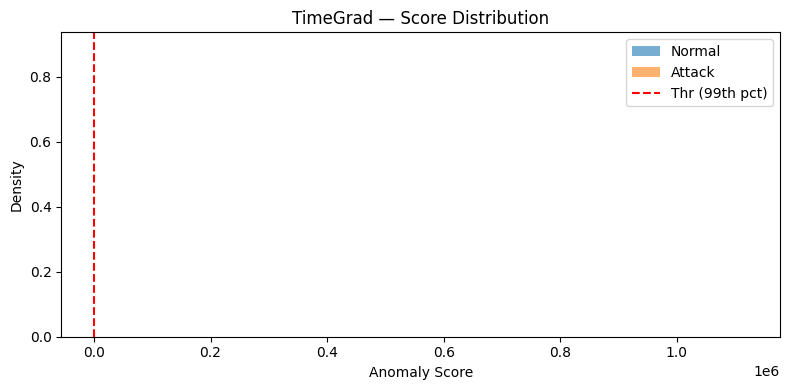


===== TimeGrad Confusion Matrix (Sequence-Level) =====
TN=50  FP=12  FN=1  TP=295
Precision: 0.9609
Recall:    0.9966
F1:        0.9784


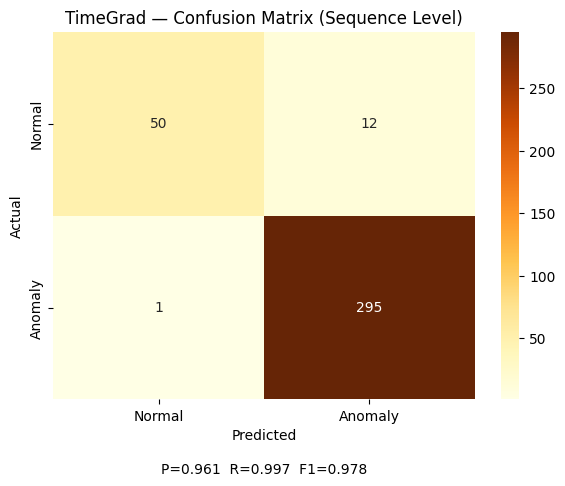

In [22]:
# --- Evaluate TimeGrad ---
tg_scores_tr = timegrad_score_sequences(timegrad_model, Xtr_all[normal_mask], schedule_tg, M=20)
tg_scores_te = timegrad_score_sequences(timegrad_model, Xte_all, schedule_tg, M=20)

tg_metrics = compute_metrics_auto_thr(yte_seq, tg_scores_te, tg_scores_tr, thr_pct=THR_PCT)
print("TimeGrad metrics:", {k: f"{v:.4f}" for k, v in tg_metrics.items()})

# Per-attack one-vs-normal breakdown (with confusion matrix components)
tg_thr = np.percentile(tg_scores_tr, THR_PCT)
attacks = sorted([a for a in np.unique(ate_seq) if a != "normal"])
pa_rows_tg = []
for atk in attacks:
    mask = (ate_seq == atk) | (ate_seq == "normal")
    y_sub = (ate_seq[mask] != "normal").astype(int)
    s_sub = tg_scores_te[mask]
    y_pred_sub = (s_sub >= tg_thr).astype(int)
    cm_sub = confusion_matrix(y_sub, y_pred_sub, labels=[0, 1])
    tn, fp, fn, tp = cm_sub.ravel()
    pa_rows_tg.append({
        "attack_type": atk,
        "n_attack_seqs": int((ate_seq[mask] == atk).sum()),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "precision": precision_score(y_sub, y_pred_sub, zero_division=0),
        "recall": recall_score(y_sub, y_pred_sub, zero_division=0),
        "f1": f1_score(y_sub, y_pred_sub, zero_division=0),
        "roc_auc": roc_auc_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
    })
print("\nPer-attack breakdown:")
display(pd.DataFrame(pa_rows_tg).sort_values("pr_auc", ascending=False).round(4))

# Score distribution
fig, ax = plt.subplots(figsize=(8, 4))
normal_s = tg_scores_te[yte_seq == 0]
attack_s = tg_scores_te[yte_seq == 1]
ax.hist(normal_s, bins=50, alpha=0.6, label="Normal", density=True)
ax.hist(attack_s, bins=50, alpha=0.6, label="Attack", density=True)
ax.axvline(tg_thr, color="red", linestyle="--", label=f"Thr ({THR_PCT}th pct)")
ax.set_title("TimeGrad — Score Distribution")
ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Density"); ax.legend()
plt.tight_layout(); plt.show()

# Confusion matrix with printed metrics
y_pred_tg = (tg_scores_te >= tg_thr).astype(int)
cm = confusion_matrix(yte_seq, y_pred_tg)
tn, fp, fn, tp = cm.ravel()
print(f"\n===== TimeGrad Confusion Matrix (Sequence-Level) =====")
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Precision: {precision_score(yte_seq, y_pred_tg):.4f}")
print(f"Recall:    {recall_score(yte_seq, y_pred_tg):.4f}")
print(f"F1:        {f1_score(yte_seq, y_pred_tg):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr", xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"], ax=ax)
ax.set_title("TimeGrad — Confusion Matrix (Sequence Level)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.text(0.5, -0.2, f"P={precision_score(yte_seq, y_pred_tg):.3f}  R={recall_score(yte_seq, y_pred_tg):.3f}  F1={f1_score(yte_seq, y_pred_tg):.3f}",
        transform=ax.transAxes, ha="center", fontsize=10)
plt.tight_layout(); plt.show()

## 10. Diffusion-TS — Interpretable Diffusion with Transformer Decomposition

**Reference:** Yuan, X. & Qiao, Y. (2024). *Diffusion-TS: Interpretable Diffusion for General Time Series Generation.* ICLR 2024.

**Core Idea:** Instead of predicting noise $\epsilon$, Diffusion-TS trains the model to **directly reconstruct the clean sample $x_0$** at each diffusion step. Uses an encoder-decoder Transformer with **disentangled temporal representations** (trend + seasonality decomposition).

**Architecture:**
- **Encoder:** Transformer encoder processes noisy input $x_n$
- **Decoder:** Decomposes output into **trend** (via moving average) and **seasonal** (via Fourier-based synthesis) components
- **Loss:** $\mathcal{L} = \mathcal{L}_{\text{recon}} + \lambda \mathcal{L}_{\text{Fourier}}$ where $\mathcal{L}_{\text{Fourier}}$ penalizes spectral discrepancy

**Anomaly Detection Adaptation:** Train on normal sequences. At test time, reconstruct via reverse diffusion and score by reconstruction error. The decomposition helps capture normal temporal structure; anomalies disrupt both trend and seasonal patterns.

**Key Difference from other frameworks:** Predicts $x_0$ directly (not noise $\epsilon$), which the paper argues leads to better interpretability and sample quality.

In [23]:
# =============================================
# Diffusion-TS — Transformer with Trend-Seasonal Decomposition
# =============================================
# Key: predicts x_0 directly (not noise epsilon), with Fourier loss.

class MovingAverage(nn.Module):
    """Simple moving average for trend extraction."""
    def __init__(self, kernel_size=5):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size, stride=1, padding=kernel_size // 2)

    def forward(self, x):
        # x: (B, T, D) → trend component
        return self.avg(x.permute(0, 2, 1)).permute(0, 2, 1)


class FourierSynthesis(nn.Module):
    """Fourier-based seasonal component synthesis."""
    def __init__(self, d_feat, n_harmonics=10):
        super().__init__()
        self.n_harmonics = n_harmonics
        # Learnable amplitudes and phases for each feature and harmonic
        self.amplitudes = nn.Parameter(torch.randn(d_feat, n_harmonics) * 0.01)
        self.phases = nn.Parameter(torch.randn(d_feat, n_harmonics) * 0.01)

    def forward(self, T, device):
        """Generate seasonal pattern of length T."""
        t = torch.arange(T, device=device, dtype=torch.float32)
        freqs = torch.arange(1, self.n_harmonics + 1, device=device, dtype=torch.float32)
        # (T, n_harmonics) basis
        basis = torch.sin(2 * math.pi * freqs.unsqueeze(0) * t.unsqueeze(1) / T + self.phases.mean(0).unsqueeze(0))
        # (D, T) = (D, n_harmonics) @ (n_harmonics, T)
        seasonal = (self.amplitudes @ basis.T)  # (D, T)
        return seasonal.T.unsqueeze(0)  # (1, T, D) — broadcast over batch


class DiffusionTSDenoiser(nn.Module):
    """
    Diffusion-TS denoiser: encoder-decoder Transformer with decomposition.
    Predicts x_0 directly (not noise).
    """
    def __init__(self, d_feat, d_model=64, nhead=4, num_layers=3, n_harmonics=10, ma_kernel=5):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(d_model),
            nn.Linear(d_model, d_model),
            nn.SiLU(),
        )
        self.in_proj = nn.Linear(d_feat, d_model)

        enc_layer = nn.TransformerEncoderLayer(d_model, nhead, d_model * 4, batch_first=True, dropout=0.1)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers)

        dec_layer = nn.TransformerDecoderLayer(d_model, nhead, d_model * 4, batch_first=True, dropout=0.1)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers)

        self.trend_proj = nn.Linear(d_model, d_feat)
        self.seasonal_proj = nn.Linear(d_model, d_feat)

        self.ma = MovingAverage(ma_kernel)
        self.fourier = FourierSynthesis(d_feat, n_harmonics)

    def forward(self, x_noisy, t):
        """
        x_noisy: (B, T_seq, D) noisy sequence
        t: (B,) timestep
        Returns: (B, T_seq, D) predicted clean x_0
        """
        B, T, D = x_noisy.shape
        t_emb = self.time_mlp(t).unsqueeze(1)  # (B, 1, d_model)

        h = self.in_proj(x_noisy)       # (B, T, d_model)
        h = h + t_emb                    # add time conditioning
        enc_out = self.encoder(h)        # (B, T, d_model)
        dec_out = self.decoder(h, enc_out)  # (B, T, d_model)

        # Decompose into trend + seasonal
        trend = self.ma(self.trend_proj(dec_out))        # (B, T, D) smoothed trend
        seasonal_base = self.fourier(T, x_noisy.device)  # (1, T, D)
        seasonal = seasonal_base + self.seasonal_proj(dec_out)  # (B, T, D)

        return trend + seasonal  # predicted x_0


def fourier_loss(pred, target):
    """Spectral loss: penalize discrepancy in frequency domain."""
    pred_fft = torch.fft.rfft(pred, dim=1)
    target_fft = torch.fft.rfft(target, dim=1)
    return F.mse_loss(pred_fft.abs(), target_fft.abs())


# =============================================
# Diffusion-TS Training (x_0 prediction, not noise prediction)
# =============================================

def train_diffusion_ts(X_train, schedule, model, *, epochs=100, batch_size=256,
                       lr=1e-4, lam_fourier=0.1, seed=42):
    """
    Train Diffusion-TS: predict x_0 directly with reconstruction + Fourier loss.
    """
    set_seed(seed)
    X_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for (x0_batch,) in loader:
            n = torch.randint(0, schedule.T, (x0_batch.size(0),), device=device)
            noise = torch.randn_like(x0_batch)
            # Noisy input (in sequence-first format)
            sqrt_ab = schedule.sqrt_alphas_bar[n].view(-1, 1, 1)
            sqrt_omab = schedule.sqrt_one_minus_alphas_bar[n].view(-1, 1, 1)
            x_noisy = sqrt_ab * x0_batch + sqrt_omab * noise

            # Predict x_0 directly
            x0_pred = model(x_noisy, n)

            loss_recon = F.mse_loss(x0_pred, x0_batch)
            loss_fft = fourier_loss(x0_pred, x0_batch)
            loss = loss_recon + lam_fourier * loss_fft

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x0_batch.size(0)

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs}  loss={total_loss/len(X_t):.6f}")


@torch.no_grad()
def diffusion_ts_score_sequences(model, X, schedule, M=50):
    """
    Score via reverse diffusion with x_0 prediction.
    At each reverse step, predict x_0, then compute x_{t-1} from it.
    Final score = reconstruction error.
    """
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    scores = []

    for i in range(0, len(X_t), 256):
        batch = X_t[i:i+256]
        B = batch.size(0)

        # Forward: add noise at level M
        t_M = torch.full((B,), M - 1, device=device, dtype=torch.long)
        x = q_sample(batch, t_M, schedule)

        # Reverse: denoise using x_0 prediction
        for step in reversed(range(M)):
            t = torch.full((B,), step, device=device, dtype=torch.long)
            x0_pred = model(x, t)  # predict x_0

            if step > 0:
                # Compute x_{t-1} from predicted x_0 using posterior
                sqrt_ab = schedule.sqrt_alphas_bar[t].view(-1, 1, 1)
                sqrt_omab = schedule.sqrt_one_minus_alphas_bar[t].view(-1, 1, 1)
                # Derive noise from x and x0_pred
                eps = (x - sqrt_ab * x0_pred) / (sqrt_omab + 1e-8)
                # Standard posterior mean
                betas = schedule.betas[t].view(-1, 1, 1)
                sqrt_recip_a = (1.0 / torch.sqrt(schedule.alphas[t])).view(-1, 1, 1)
                mean = sqrt_recip_a * (x - betas / sqrt_omab * eps)
                sigma = torch.sqrt(schedule.posterior_var[t]).view(-1, 1, 1)
                x = mean + sigma * torch.randn_like(x)
            else:
                x = x0_pred

        err = (batch - x).pow(2).mean(dim=(1, 2))
        scores.append(err.cpu().numpy())

    return np.concatenate(scores)


# --- Train Diffusion-TS ---
print("Training Diffusion-TS model...")
schedule_dts = DiffusionSchedule(N_DIFF_STEPS, schedule="cosine").to(device)
diffts_model = DiffusionTSDenoiser(D_feat, d_model=64, nhead=4, num_layers=3).to(device)
print(f"  Model params: {model_size_stats(diffts_model)}")
train_diffusion_ts(Xtr_normal, schedule_dts, diffts_model,
                   epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, lam_fourier=0.1, seed=SEED)

Training Diffusion-TS model...
  Model params: {'Params': 357214, 'Size (MB)': 1.3626632690429688}
  Epoch 20/100  loss=3.160629
  Epoch 40/100  loss=2.865842
  Epoch 60/100  loss=2.717680
  Epoch 80/100  loss=2.401704
  Epoch 100/100  loss=2.302935


Diffusion-TS metrics: {'roc_auc': '0.9744', 'pr_auc': '0.9918', 'f1': '0.9768', 'precision': '0.9578', 'recall': '0.9966', 'accuracy': '0.9609'}

Per-attack breakdown:


,attack_type,n_attack_seqs,TN,FP,FN,TP,precision,recall,f1,roc_auc,pr_auc
3,M_F,58,49,13,0,58,0.8169,1.0000,0.8992,1.0000,1.0000
4,P_I,30,49,13,0,30,0.6977,1.0000,0.8219,1.0000,1.0000
2,F_I,60,49,13,0,60,0.8219,1.0000,0.9023,0.9737,0.9418
1,C_R,81,49,13,0,81,0.8617,1.0000,0.9257,0.9608,0.9071
0,C_D,67,49,13,1,66,0.8354,0.9851,0.9041,0.9579,0.8938


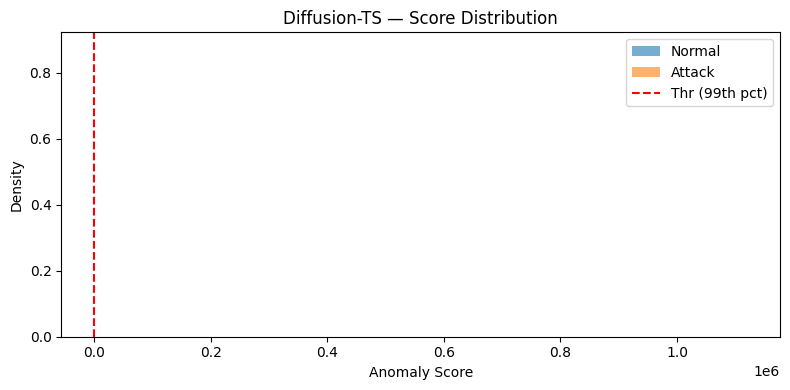


===== Diffusion-TS Confusion Matrix (Sequence-Level) =====
TN=49  FP=13  FN=1  TP=295
Precision: 0.9578
Recall:    0.9966
F1:        0.9768


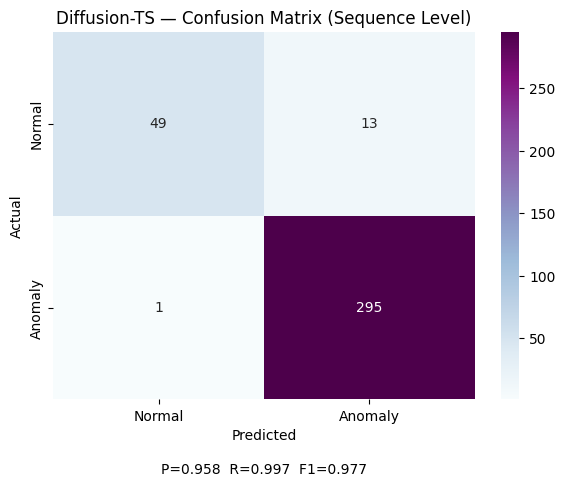

In [24]:
# --- Evaluate Diffusion-TS ---
dts_scores_tr = diffusion_ts_score_sequences(diffts_model, Xtr_all[normal_mask], schedule_dts, M=M_SCORE)
dts_scores_te = diffusion_ts_score_sequences(diffts_model, Xte_all, schedule_dts, M=M_SCORE)

dts_metrics = compute_metrics_auto_thr(yte_seq, dts_scores_te, dts_scores_tr, thr_pct=THR_PCT)
print("Diffusion-TS metrics:", {k: f"{v:.4f}" for k, v in dts_metrics.items()})

# Per-attack one-vs-normal breakdown (with confusion matrix components)
dts_thr = np.percentile(dts_scores_tr, THR_PCT)
attacks = sorted([a for a in np.unique(ate_seq) if a != "normal"])
pa_rows_dts = []
for atk in attacks:
    mask = (ate_seq == atk) | (ate_seq == "normal")
    y_sub = (ate_seq[mask] != "normal").astype(int)
    s_sub = dts_scores_te[mask]
    y_pred_sub = (s_sub >= dts_thr).astype(int)
    cm_sub = confusion_matrix(y_sub, y_pred_sub, labels=[0, 1])
    tn, fp, fn, tp = cm_sub.ravel()
    pa_rows_dts.append({
        "attack_type": atk,
        "n_attack_seqs": int((ate_seq[mask] == atk).sum()),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "precision": precision_score(y_sub, y_pred_sub, zero_division=0),
        "recall": recall_score(y_sub, y_pred_sub, zero_division=0),
        "f1": f1_score(y_sub, y_pred_sub, zero_division=0),
        "roc_auc": roc_auc_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_sub, s_sub) if len(np.unique(y_sub)) > 1 else np.nan,
    })
print("\nPer-attack breakdown:")
display(pd.DataFrame(pa_rows_dts).sort_values("pr_auc", ascending=False).round(4))

# Score distribution
fig, ax = plt.subplots(figsize=(8, 4))
normal_s = dts_scores_te[yte_seq == 0]
attack_s = dts_scores_te[yte_seq == 1]
ax.hist(normal_s, bins=50, alpha=0.6, label="Normal", density=True)
ax.hist(attack_s, bins=50, alpha=0.6, label="Attack", density=True)
ax.axvline(dts_thr, color="red", linestyle="--", label=f"Thr ({THR_PCT}th pct)")
ax.set_title("Diffusion-TS — Score Distribution")
ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Density"); ax.legend()
plt.tight_layout(); plt.show()

# Confusion matrix with printed metrics
y_pred_dts = (dts_scores_te >= dts_thr).astype(int)
cm = confusion_matrix(yte_seq, y_pred_dts)
tn, fp, fn, tp = cm.ravel()
print(f"\n===== Diffusion-TS Confusion Matrix (Sequence-Level) =====")
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Precision: {precision_score(yte_seq, y_pred_dts):.4f}")
print(f"Recall:    {recall_score(yte_seq, y_pred_dts):.4f}")
print(f"F1:        {f1_score(yte_seq, y_pred_dts):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="BuPu", xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"], ax=ax)
ax.set_title("Diffusion-TS — Confusion Matrix (Sequence Level)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.text(0.5, -0.2, f"P={precision_score(yte_seq, y_pred_dts):.3f}  R={recall_score(yte_seq, y_pred_dts):.3f}  F1={f1_score(yte_seq, y_pred_dts):.3f}",
        transform=ax.transAxes, ha="center", fontsize=10)
plt.tight_layout(); plt.show()

## 11. Confusion Matrices — All Frameworks

Side-by-side confusion matrices at sequence level for all seven diffusion-based models.

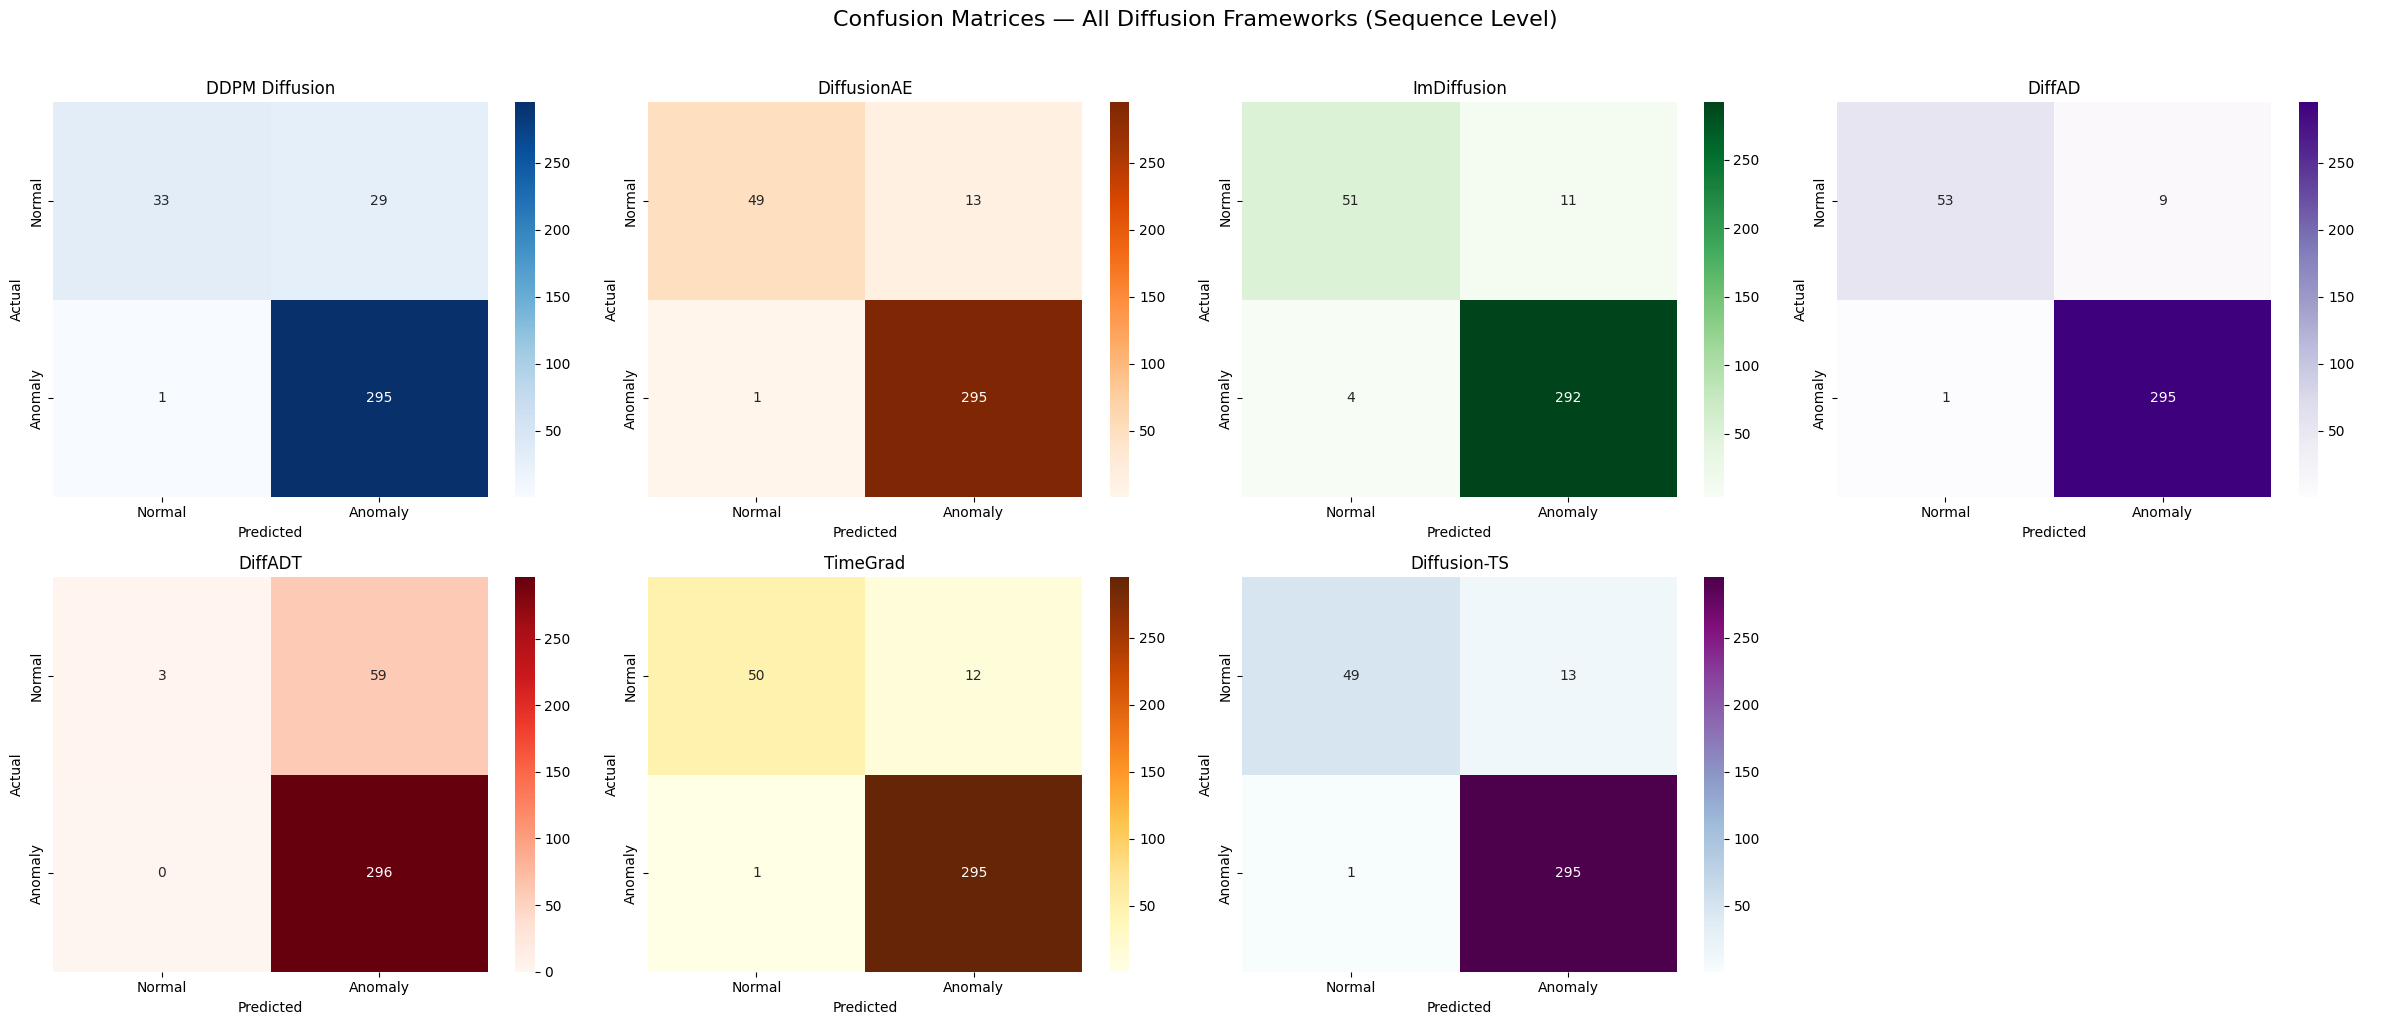

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle("Confusion Matrices — All Diffusion Frameworks (Sequence Level)", fontsize=16, y=1.02)

all_preds = [
    ("DDPM Diffusion", y_pred_ddpm, "Blues"),
    ("DiffusionAE", y_pred_dae, "Oranges"),
    ("ImDiffusion", y_pred_imd, "Greens"),
    ("DiffAD", y_pred_dad, "Purples"),
    ("DiffADT", y_pred_adt, "Reds"),
    ("TimeGrad", y_pred_tg, "YlOrBr"),
    ("Diffusion-TS", y_pred_dts, "BuPu"),
]

for idx, (name, y_pred, cmap) in enumerate(all_preds):
    row, col = divmod(idx, 4)
    ax = axes[row, col]
    cm = confusion_matrix(yte_seq, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

# Hide unused subplot
axes[1, 3].axis("off")
plt.tight_layout()
plt.show()

## 12. Model Size, Latency & Energy

In [26]:
# Model sizes
print("Model sizes:")
print("  DDPM Diffusion:", model_size_stats(ddpm_model))
print("  DiffusionAE:   ", combined_model_size(dae_autoencoder, dae_diffusion))
print("  ImDiffusion:   ", model_size_stats(imdiff_model))
print("  DiffAD:        ", model_size_stats(diffad_model))
print("  DiffADT:       ", model_size_stats(diffadt_model))
print("  TimeGrad:      ", model_size_stats(timegrad_model))
print("  Diffusion-TS:  ", model_size_stats(diffts_model))

# One-inference functions for latency/energy profiling
X_sample_seq = Xte_all[:1]  # single sequence for profiling
X_sample_cf = torch.tensor(X_sample_seq, dtype=torch.float32).permute(0, 2, 1).to(device)
X_sample_tf = torch.tensor(X_sample_seq, dtype=torch.float32).to(device)

def ddpm_one():
    diffusion_score_sequences(ddpm_model, X_sample_seq, schedule_ddpm, M=M_SCORE)
def dae_one():
    diffusion_ae_score_sequences(dae_autoencoder, dae_diffusion, X_sample_seq, schedule_dae, M=M_SCORE)
def imd_one():
    imdiffusion_score_sequences(imdiff_model, X_sample_seq, schedule_imd, M=M_SCORE, n_passes=1, seed=0)
def dad_one():
    diffad_score_sequences(diffad_model, X_sample_seq, schedule_dad, M=M_SCORE, seed=0)
def adt_one():
    diffadt_score_sequences(diffadt_model, X_sample_seq, schedule_adt, M=20)
def tg_one():
    timegrad_score_sequences(timegrad_model, X_sample_seq, schedule_tg, M=20)
def dts_one():
    diffusion_ts_score_sequences(diffts_model, X_sample_seq, schedule_dts, M=M_SCORE)

workloads = [
    ("DDPM Diffusion", ddpm_one, model_size_stats(ddpm_model)),
    ("DiffusionAE", dae_one, combined_model_size(dae_autoencoder, dae_diffusion)),
    ("ImDiffusion", imd_one, model_size_stats(imdiff_model)),
    ("DiffAD", dad_one, model_size_stats(diffad_model)),
    ("DiffADT", adt_one, model_size_stats(diffadt_model)),
    ("TimeGrad", tg_one, model_size_stats(timegrad_model)),
    ("Diffusion-TS", dts_one, model_size_stats(diffts_model)),
]

profile_rows = []
for name, fn, size in workloads:
    peak_mem = measure_peak_cuda_mem_mb(fn)
    prof = profile_workload(fn, repeats=50)
    profile_rows.append({
        "Model": name,
        **size,
        "Peak CUDA (MB)": round(peak_mem, 2),
        **{k: round(v, 4) if isinstance(v, float) else v for k, v in prof.items()},
    })
    print(f"{name}: {prof['Latency (ms)']:.3f} ms/call, {prof['Energy (J/call)']:.6f} J/call")

df_profile = pd.DataFrame(profile_rows)
display(df_profile)

Model sizes:
  DDPM Diffusion: {'Params': 2673127, 'Size (MB)': 10.19717025756836}
  DiffusionAE:    {'Params': 2842292, 'Size (MB)': 10.842483520507812}
  ImDiffusion:    {'Params': 2682045, 'Size (MB)': 10.231189727783203}
  DiffAD:         {'Params': 1236493, 'Size (MB)': 4.716846466064453}
  DiffADT:        {'Params': 2124813, 'Size (MB)': 8.105518341064453}
  TimeGrad:       {'Params': 280013, 'Size (MB)': 1.0681648254394531}
  Diffusion-TS:   {'Params': 357214, 'Size (MB)': 1.3626632690429688}
DDPM Diffusion: 233.891 ms/call, 16.975978 J/call
DiffusionAE: 268.907 ms/call, 19.453186 J/call
ImDiffusion: 276.584 ms/call, 19.979137 J/call
DiffAD: 649.110 ms/call, 46.077202 J/call
DiffADT: 863.749 ms/call, 61.907138 J/call
TimeGrad: 685.116 ms/call, 49.583651 J/call
Diffusion-TS: 241.348 ms/call, 18.299045 J/call


,Model,Params,Size (MB),Peak CUDA (MB),Elapsed (s),Latency (ms),Throughput (calls/s),GPU Power Avg (W),GPU Power Peak (W),GPU Util Avg (%),GPU Mem Avg (MB),GPU Mem Peak (MB),CPU Util Avg (%),RSS Peak (MB),Energy Total (J),Energy (J/call)
0,DDPM Diffusion,2673127,10.197170,112.27,11.6946,233.8913,4.2755,72.6008,73.579,66.7928,5318.8476,5328.8164,8.0331,2011.0977,848.7989,16.9760
1,DiffusionAE,2842292,10.842484,112.27,13.4453,268.9067,3.7188,72.4057,73.570,69.5643,5522.4756,5623.2266,8.6678,2011.0977,972.6593,19.4532
2,ImDiffusion,2682045,10.231190,112.29,13.8292,276.5842,3.6155,72.3170,73.370,71.9892,5487.4846,5508.5703,8.3008,2011.0977,998.9568,19.9791
3,DiffAD,1236493,4.716846,127.75,32.4555,649.1101,1.5406,71.0243,72.131,72.4059,5405.5337,5526.7656,8.3954,2011.0977,2303.8601,46.0772
4,DiffADT,2124813,8.105518,127.77,43.1875,863.7494,1.1577,71.6323,73.328,78.3093,5248.8897,5362.0938,8.4000,2011.0977,3095.3569,61.9071
5,TimeGrad,280013,1.068165,111.40,34.2558,685.1160,1.4596,72.5610,74.387,78.7214,5335.8395,5372.1562,8.3927,2011.2852,2479.1825,49.5837
6,Diffusion-TS,357214,1.362663,111.45,12.0674,241.3483,4.1434,75.8515,76.735,83.0591,5328.7155,5328.7695,8.3034,2011.2852,914.9522,18.2990


## 13. Final Deployment Comparison

Unified table combining detection metrics, model size, latency, and energy for all diffusion frameworks. This enables direct comparison with the GAN-based and classical ML baselines from the **TOW-IDS ML** notebook.

In [27]:
# =============================================
# Final Comparison Table
# =============================================

all_metrics = [
    ("DDPM Diffusion", ddpm_metrics, "Reconstruction"),
    ("DiffusionAE", dae_metrics, "AE + Diffusion"),
    ("ImDiffusion", imd_metrics, "Imputation"),
    ("DiffAD", dad_metrics, "Imp. + Weight-Inc."),
    ("DiffADT", adt_metrics, "Recon. + S4"),
    ("TimeGrad", tg_metrics, "AR Forecasting"),
    ("Diffusion-TS", dts_metrics, "Gen. + Decomp."),
]

final_rows = []
for (name, metrics, paradigm), prof_row in zip(all_metrics, profile_rows):
    final_rows.append({
        "Model": name,
        "Paradigm": paradigm,
        "ROC-AUC": round(metrics.get("roc_auc", float("nan")), 4),
        "PR-AUC": round(metrics.get("pr_auc", float("nan")), 4),
        "F1": round(metrics.get("f1", float("nan")), 4),
        "Precision": round(metrics.get("precision", float("nan")), 4),
        "Recall": round(metrics.get("recall", float("nan")), 4),
        "Params": prof_row["Params"],
        "Size (MB)": prof_row["Size (MB)"],
        "Latency (ms)": prof_row["Latency (ms)"],
        "Throughput (calls/s)": prof_row["Throughput (calls/s)"],
        "GPU Power Avg (W)": prof_row["GPU Power Avg (W)"],
        "GPU Util Avg (%)": prof_row["GPU Util Avg (%)"],
        "GPU Mem Peak (MB)": prof_row["GPU Mem Peak (MB)"],
        "CPU Util Avg (%)": prof_row["CPU Util Avg (%)"],
        "RSS Peak (MB)": prof_row["RSS Peak (MB)"],
        "Peak CUDA (MB)": prof_row["Peak CUDA (MB)"],
        "Energy (J/call)": prof_row["Energy (J/call)"],
    })

df_final = pd.DataFrame(final_rows)
print("=" * 120)
print("FINAL DEPLOYMENT COMPARISON — Diffusion-based MTS Anomaly Detection")
print("=" * 120)
display(df_final)

# Highlight best model per metric
print("\nBest models:")
for metric in ["ROC-AUC", "PR-AUC", "F1"]:
    best_idx = df_final[metric].idxmax()
    print(f"  {metric}: {df_final.loc[best_idx, 'Model']} ({df_final.loc[best_idx, metric]:.4f})")
print(f"  Smallest: {df_final.loc[df_final['Params'].idxmin(), 'Model']} ({df_final.loc[df_final['Params'].idxmin(), 'Params']} params)")
print(f"  Fastest:  {df_final.loc[df_final['Latency (ms)'].idxmin(), 'Model']} ({df_final.loc[df_final['Latency (ms)'].idxmin(), 'Latency (ms)']:.1f} ms)")

FINAL DEPLOYMENT COMPARISON — Diffusion-based MTS Anomaly Detection


,Model,Paradigm,ROC-AUC,PR-AUC,F1,Precision,Recall,Params,Size (MB),Latency (ms),Throughput (calls/s),GPU Power Avg (W),GPU Util Avg (%),GPU Mem Peak (MB),CPU Util Avg (%),RSS Peak (MB),Peak CUDA (MB),Energy (J/call)
0,DDPM Diffusion,Reconstruction,0.9736,0.9915,0.9516,0.9105,0.9966,2673127,10.197170,233.8913,4.2755,72.6008,66.7928,5328.8164,8.0331,2011.0977,112.27,16.9760
1,DiffusionAE,AE + Diffusion,0.9741,0.9917,0.9768,0.9578,0.9966,2842292,10.842484,268.9067,3.7188,72.4057,69.5643,5623.2266,8.6678,2011.0977,112.27,19.4532
2,ImDiffusion,Imputation,0.9725,0.9917,0.9750,0.9637,0.9865,2682045,10.231190,276.5842,3.6155,72.3170,71.9892,5508.5703,8.3008,2011.0977,112.29,19.9791
3,DiffAD,Imp. + Weight-Inc.,0.9759,0.9919,0.9833,0.9704,0.9966,1236493,4.716846,649.1101,1.5406,71.0243,72.4059,5526.7656,8.3954,2011.0977,127.75,46.0772
4,DiffADT,Recon. + S4,0.9896,0.9978,0.9094,0.8338,1.0000,2124813,8.105518,863.7494,1.1577,71.6323,78.3093,5362.0938,8.4000,2011.0977,127.77,61.9071
5,TimeGrad,AR Forecasting,0.9740,0.9918,0.9784,0.9609,0.9966,280013,1.068165,685.1160,1.4596,72.5610,78.7214,5372.1562,8.3927,2011.2852,111.40,49.5837
6,Diffusion-TS,Gen. + Decomp.,0.9744,0.9918,0.9768,0.9578,0.9966,357214,1.362663,241.3483,4.1434,75.8515,83.0591,5328.7695,8.3034,2011.2852,111.45,18.2990



Best models:
  ROC-AUC: DiffADT (0.9896)
  PR-AUC: DiffADT (0.9978)
  F1: DiffAD (0.9833)
  Smallest: TimeGrad (280013 params)
  Fastest:  DDPM Diffusion (233.9 ms)


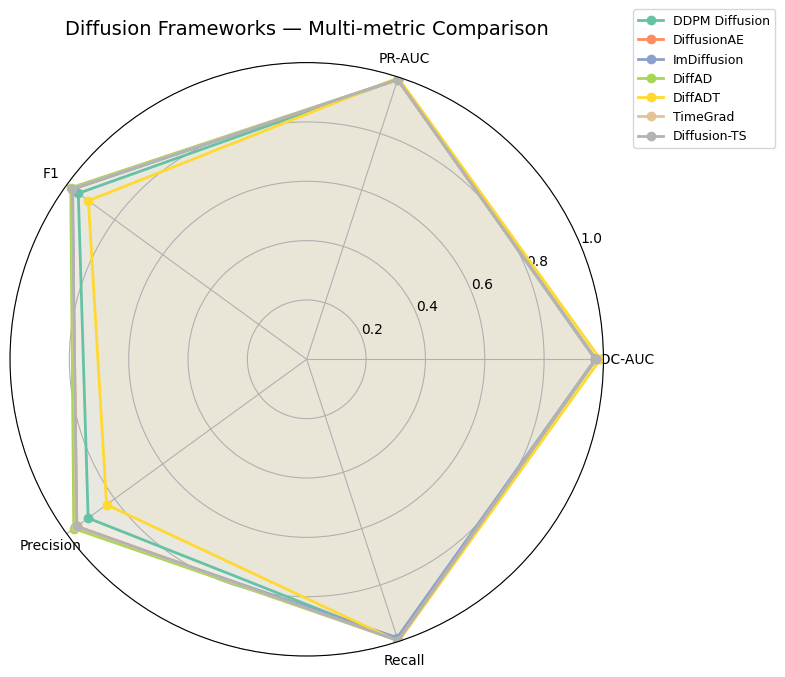

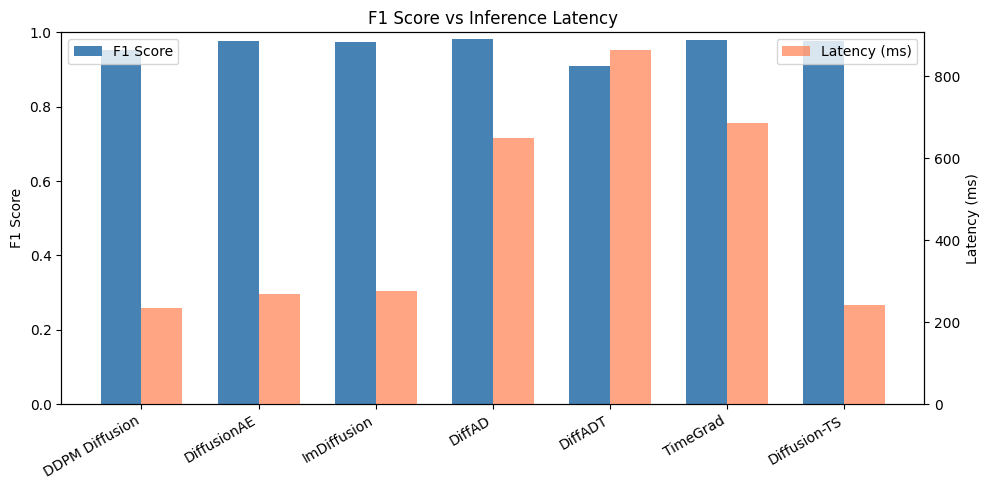

In [28]:
# =============================================
# Radar Chart — Multi-metric Comparison
# =============================================
from matplotlib.patches import FancyBboxPatch

metrics_to_plot = ["ROC-AUC", "PR-AUC", "F1", "Precision", "Recall"]
models = df_final["Model"].tolist()
n_metrics = len(metrics_to_plot)

angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = plt.cm.Set2(np.linspace(0, 1, len(models)))

for i, model in enumerate(models):
    values = df_final[df_final["Model"] == model][metrics_to_plot].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=model, color=colors[i])
    ax.fill(angles, values, alpha=0.05, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1)
ax.set_title("Diffusion Frameworks — Multi-metric Comparison", size=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

# Bar chart: Latency vs F1
fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(models))
width = 0.35
bars1 = ax1.bar(x - width/2, df_final["F1"], width, label="F1 Score", color="steelblue")
ax1.set_ylabel("F1 Score")
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, df_final["Latency (ms)"], width, label="Latency (ms)", color="coral", alpha=0.7)
ax2.set_ylabel("Latency (ms)")

ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30, ha="right")
ax1.set_title("F1 Score vs Inference Latency")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()